# CISI Frequency Domain Absolute Power — All Times  
## Centered to a global across-trial mean baseline

This notebook only does the **frequency-domain absolute power, all-times** analysis.

### What is different here?
In your earlier baseline-centered version, each trial was centered to its own **pre-stimulus** baseline window (`-500 ms to -50 ms`).

In **this** notebook, the baseline is defined differently:

- First compute the **absolute band power** for each trial using the **full epoch** ("all times")
- Then, for each **subject** and each **frequency band**, compute the **average of those trial powers across all trials**
- That one average value becomes the **global baseline** for that subject and band
- Then subtract that same baseline from every trial in that subject and band

So the centering is now:

\[
\text{centered power}_{trial,band} = \text{raw power}_{trial,band} - \overline{\text{raw power}}_{all\ trials,band}
\]

This means:
- `0` = equal to that subject's average full-epoch power for that band
- `> 0` = above that subject's across-trial average
- `< 0` = below that subject's across-trial average


> Note: This CISI copy was converted from the CISI notebook by changing CISI labels, condition names, channel labels, and output filenames to CISI. The time windows were kept the same as the CISI notebook for now (`0–500 ms` and `500–1000 ms`). If CISI uses different event timing, update the `tmin`/`tmax` values in the window-specific cells before running those sections.


In [4]:

# NumPy handles arrays, indexing, and mathematical operations.
import numpy as np

# Pandas stores trial-by-band tables and makes averaging easier.
import pandas as pd

# Matplotlib is used to make the figures.
import matplotlib.pyplot as plt

# These imports let us silence extra warnings / printouts from the helper functions.
import warnings
import contextlib
import io

# These project helper functions are already used elsewhere in your notebook.
# - load_eeg_data loads the epochs for one subject
# - compute_frequency_power computes frequency-domain band power per trial
from utils import load_eeg_data, compute_frequency_power

# Show plots directly inside the notebook.
%matplotlib inline

# Slightly increase default display quality so the plots are easier to read.
plt.rcParams.update({'figure.dpi': 120, 'font.size': 10})


In [5]:

# These are the subjects used in your CISI analysis.
SUBJECTS = [2, 3, 5, 6, 7, 8, 9, 10, 11, 12, 13, 15, 16, 17]

# CONDITION tells the loader which task / dataset to open.
# For CISI, the working notebook loads the data using the P1 condition label.
CONDITION = "P1"

# CHANNELS tells the loader which ROI channel group to use.
# For CISI, the working notebook also uses the P1 channel label.
CHANNELS = "P1"

# These are the frequency bands that will be plotted in the final figure.
bands = ['delta', 'theta', 'alpha', 'beta', 'gamma']

# These colors are only for plotting so each band has a consistent visual identity.
colors = ['blue', 'green', 'red', 'orange', 'purple']

# The rolling window is only for the thick black trend line.
# It smooths the visual trend but does NOT alter the stored trial values.
ROLLING_WINDOW = 5

# This label is just text for titles / print statements so you remember
# what kind of baseline this notebook is using.
BASELINE_LABEL = "global average over all times and all trials"

print(f"Analyzing {len(SUBJECTS)} subjects: {SUBJECTS}")
print(f"Condition: {CONDITION}")
print(f"Channels: {CHANNELS}")
print(f"Baseline definition: {BASELINE_LABEL}")


Analyzing 14 subjects: [2, 3, 5, 6, 7, 8, 9, 10, 11, 12, 13, 15, 16, 17]
Condition: P1
Channels: P1
Baseline definition: global average over all times and all trials


In [6]:
# Safety imports so this cell still works if the import cell was not run first.
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import warnings
import contextlib
import io
from utils import load_eeg_data, compute_frequency_power


# These dictionaries store the trial-level outputs for each subject.
# all_power_pivots_raw[subject_id]
#     Raw absolute power for each trial and band before centering.
#
# all_global_baseline_pivots[subject_id]
#     One-row table containing the subject's across-trial mean power
#     for each band. This is the baseline that gets subtracted.
#
# all_power_pivots_centered[subject_id]
#     Raw trial power minus that subject's global band-wise baseline.
#
# all_psds_dicts[subject_id]
#     Extra PSD output returned by compute_frequency_power, saved in case
#     you want to inspect it later.
all_power_pivots_raw = {}
all_global_baseline_pivots = {}
all_power_pivots_centered = {}
all_psds_dicts = {}

# Keep track of which subjects processed successfully.
processed_subjects = []

# Keep track of failures so the notebook does not crash on one bad subject.
failed_subjects = []

# Loop over subjects one at a time so we can compute each subject's trial-level power.
for subject_id in SUBJECTS:
    try:
        # Silence extra warnings and console spam so the notebook output stays clean.
        with warnings.catch_warnings():
            warnings.simplefilter("ignore")
            with contextlib.redirect_stdout(io.StringIO()), contextlib.redirect_stderr(io.StringIO()):

                # Load the epoched CISI data for this subject.
                epochs = load_eeg_data(
                    CONDITION,
                    subject_id,
                    channels=CHANNELS,
                    freq_band="delta_gamma"
                )

                # Compute frequency-domain absolute power across the full epoch ("all times").
                # The helper returns:
                # - power_df: a long-format table with columns like trial, band, power
                # - psds_dict: extra PSD information saved for reference
                power_df, psds_dict = compute_frequency_power(epochs, fmin=0.5, fmax=45)

        # Convert the long-format power table into a trial x band matrix.
        #
        # groupby(['trial', 'band'])['power'].mean()
        #     If there are multiple rows per trial-band pair, average them first.
        #
        # unstack()
        #     Move the band labels out into separate columns.
        #
        # reindex(columns=bands)
        #     Force a consistent column order: delta, theta, alpha, beta, gamma.
        power_pivot_raw = (
            power_df.groupby(['trial', 'band'])['power']
            .mean()
            .unstack()
            .reindex(columns=bands)
        )

        # Compute the global baseline for this subject.
        #
        # power_pivot_raw.mean(axis=0)
        #     Average DOWN the rows, so for each band we get one number:
        #     the mean power across ALL trials for that subject.
        #
        # This is the key change in this notebook.
        # We are NOT using a pre-stimulus crop anymore.
        # We are using the average full-epoch power across all trials.
        global_baseline = power_pivot_raw.mean(axis=0)

        # Turn that Series into a 1-row DataFrame so it is easy to inspect later.
        # The single row represents the subject's band-wise baseline values.
        global_baseline_pivot = pd.DataFrame([global_baseline], columns=bands)

        # Center each trial by subtracting the same band-specific baseline value.
        #
        # Because pandas aligns by column name, each trial's delta value gets
        # delta's baseline subtracted, alpha gets alpha's baseline subtracted, etc.
        power_pivot_centered = power_pivot_raw - global_baseline

        # Save everything for later plotting.
        all_power_pivots_raw[subject_id] = power_pivot_raw
        all_global_baseline_pivots[subject_id] = global_baseline_pivot
        all_power_pivots_centered[subject_id] = power_pivot_centered
        all_psds_dicts[subject_id] = psds_dict

        # Record that this subject finished successfully.
        processed_subjects.append(subject_id)

    except Exception as e:
        # Save the error message rather than stopping the whole notebook.
        failed_subjects.append((subject_id, str(e)))

print("Processed successfully:", processed_subjects)

if failed_subjects:
    print("\nFailed:")
    for subject_id, err in failed_subjects:
        print(f"Subject {subject_id}: {err}")


Processed successfully: [2, 3, 5, 6, 7, 8, 9, 10, 11, 12, 13, 15, 16, 17]


In [7]:

# These dictionaries will store the grand-average centered power across subjects
# for each band, plus the SEM at each trial index.
grand_power = {}
grand_sem = {}

# Loop through one frequency band at a time.
for band in bands:

    # This list will hold one vector per subject.
    # Each vector is that subject's centered power across trials for this band.
    band_trials = []

    # Go through all successfully processed subjects.
    for subject_id in processed_subjects:

        # Pull out that subject's centered trial x band table.
        power_pivot = all_power_pivots_centered[subject_id]

        # Only continue if this band is present in the table.
        if band in power_pivot.columns:

            # Extract the one column for this band.
            #
            # reset_index(drop=True) makes the row labels run 0, 1, 2, ...
            # This matters when we concatenate subjects side by side:
            # we want alignment by trial position, not by any leftover index labels.
            band_trials.append(power_pivot[band].reset_index(drop=True))

    # Only compute the grand average if at least one subject contributed data.
    if band_trials:

        # Combine all subject vectors side by side into one table.
        #
        # Rows = trial index
        # Columns = subject
        band_df = pd.concat(band_trials, axis=1)

        # Compute the grand mean across subjects for each trial index.
        #
        # mean(axis=1) means:
        # average ACROSS columns, so across subjects, row by row.
        grand_power[band] = band_df.mean(axis=1)

        # Compute the standard error of the mean (SEM) across subjects.
        #
        # std(axis=1) gives the standard deviation across subjects at each trial.
        # Dividing by sqrt(N) converts that to SEM.
        grand_sem[band] = band_df.std(axis=1) / np.sqrt(band_df.shape[1])


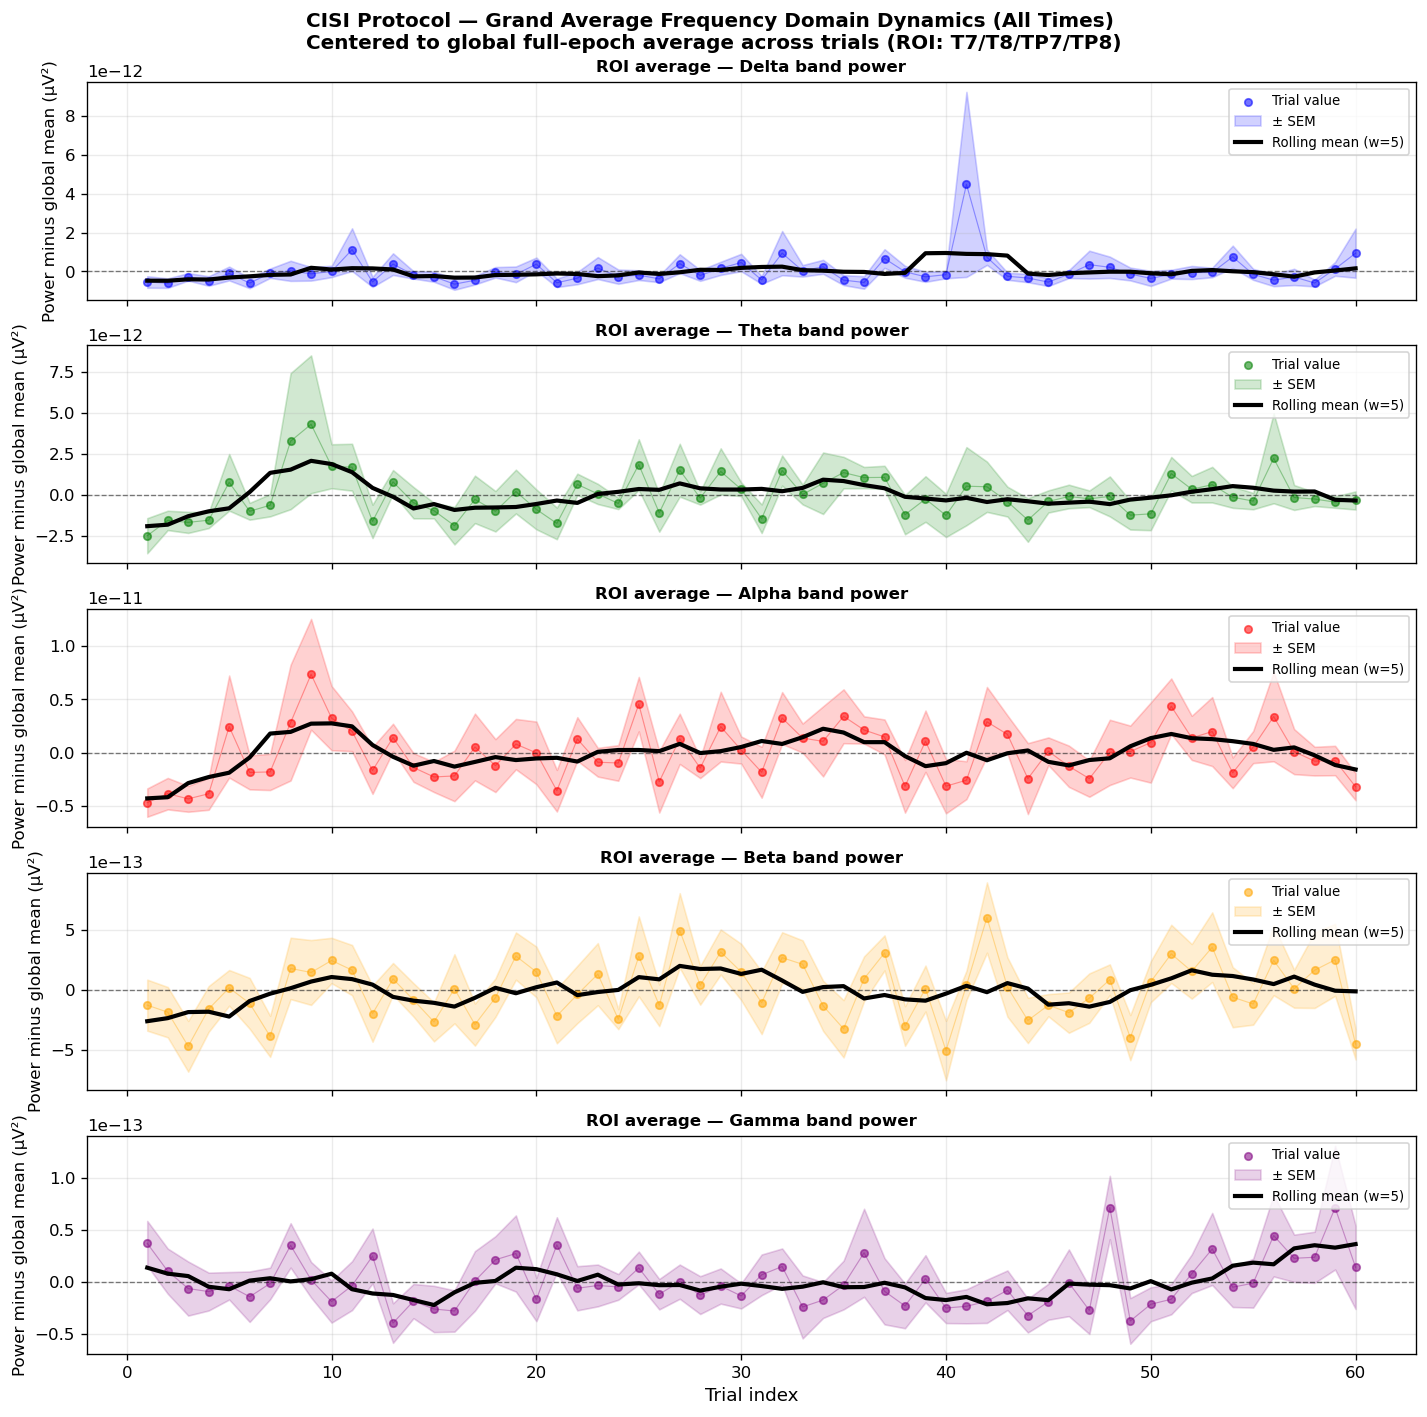

Figure saved: frequency_dynamics_CISI_global_mean_centered.png
Analysis completed for subjects: [2, 3, 5, 6, 7, 8, 9, 10, 11, 12, 13, 15, 16, 17]
Values above 0 are above the subject's across-trial mean for that band.
Values below 0 are below the subject's across-trial mean for that band.


In [8]:

# Create one subplot per band so each frequency range gets its own panel.
fig, axes = plt.subplots(len(bands), 1, figsize=(12, 12), sharex=True)

# Loop over each band and its matching plot color.
for i, (band, color) in enumerate(zip(bands, colors)):

    # Select the subplot for this band.
    ax = axes[i]

    # Only plot if data exists for this band.
    if band in grand_power:

        # Pull the grand-average centered values into a NumPy array for plotting.
        values = grand_power[band].values

        # Pull the SEM values for the same trial positions.
        errors = grand_sem[band].values

        # Build the x-axis as trial numbers starting at 1 instead of 0.
        trial_idx = np.arange(1, len(values) + 1)

        # Plot the trial-by-trial grand mean as scatter points.
        # Each point is one trial index after averaging across subjects.
        ax.scatter(
            trial_idx,
            values,
            color=color,
            s=20,
            alpha=0.55,
            zorder=2,
            label='Trial value'
        )

        # Draw a faint thin line through the same points.
        # This does not add new data; it just makes the sequence easier to follow visually.
        ax.plot(
            trial_idx,
            values,
            color=color,
            linewidth=0.7,
            alpha=0.35,
            zorder=1
        )

        # Fill between mean - SEM and mean + SEM.
        # This gives a visual sense of uncertainty around the grand mean.
        ax.fill_between(
            trial_idx,
            values - errors,
            values + errors,
            color=color,
            alpha=0.18,
            zorder=1,
            label='± SEM'
        )

        # Compute a rolling mean for a smoother trend line.
        #
        # center=True centers the smoothing window on each trial.
        # min_periods=1 prevents NaNs at the edges by allowing smaller edge windows.
        rolling = pd.Series(values).rolling(
            window=ROLLING_WINDOW,
            center=True,
            min_periods=1
        ).mean()

        # Plot the rolling mean as a thicker black trend line.
        ax.plot(
            trial_idx,
            rolling,
            color='black',
            linewidth=2.5,
            zorder=3,
            label=f'Rolling mean (w={ROLLING_WINDOW})'
        )

    # Label the y-axis.
    # These values are no longer "power minus pre-stimulus baseline."
    # They are "power minus subject's global across-trial mean for that band."
    ax.set_ylabel('Power minus global mean (µV²)', fontsize=10)

    # Give each subplot a descriptive title.
    ax.set_title(
        f'ROI average — {band.capitalize()} band power',
        fontsize=10,
        fontweight='bold'
    )

    # Add a horizontal zero line.
    # Because of the centering, 0 means "equal to the subject-level global baseline."
    ax.axhline(0, color='black', linewidth=0.8, linestyle='--', alpha=0.5)

    # Show the legend.
    ax.legend(loc='upper right', fontsize=8)

    # Add a light grid so trial-to-trial changes are easier to see.
    ax.grid(True, alpha=0.25)

# Label the shared x-axis on the bottom subplot only.
axes[-1].set_xlabel('Trial index', fontsize=11)

# Add one overall figure title.
fig.suptitle(
    'CISI Protocol — Grand Average Frequency Domain Dynamics (All Times) \n'
    'Centered to global full-epoch average across trials (ROI: T7/T8/TP7/TP8)',
    fontsize=12,
    fontweight='bold'
)

# Tight layout reduces overlap between titles, axes, and labels.
fig.tight_layout()

# Save the figure to disk so you can reuse it outside the notebook.
plt.savefig('frequency_dynamics_CISI_global_mean_centered.png', bbox_inches='tight', dpi=150)

# Display the figure in the notebook.
plt.show()

print("Figure saved: frequency_dynamics_CISI_global_mean_centered.png")
print(f"Analysis completed for subjects: {processed_subjects}")
print("Values above 0 are above the subject's across-trial mean for that band.")
print("Values below 0 are below the subject's across-trial mean for that band.")


In [9]:

# This optional cell lets you inspect the actual global baseline values
# that were subtracted for one example subject.

# Pick the first successfully processed subject.
example_subject = processed_subjects[0]

print(f"Example subject: {example_subject}")
print("One-row table of global band-wise baseline values:")

all_global_baseline_pivots[example_subject]


Example subject: 2
One-row table of global band-wise baseline values:


,delta,theta,alpha,beta,gamma
0,4.448193e-12,4.527247e-12,5.482291e-12,5.102628e-12,7.786561e-13


-500–0 ms frequency-domain absolute-power subjects processed: [2, 3, 5, 6, 7, 8, 9, 10, 11, 12, 13, 15, 16, 17]


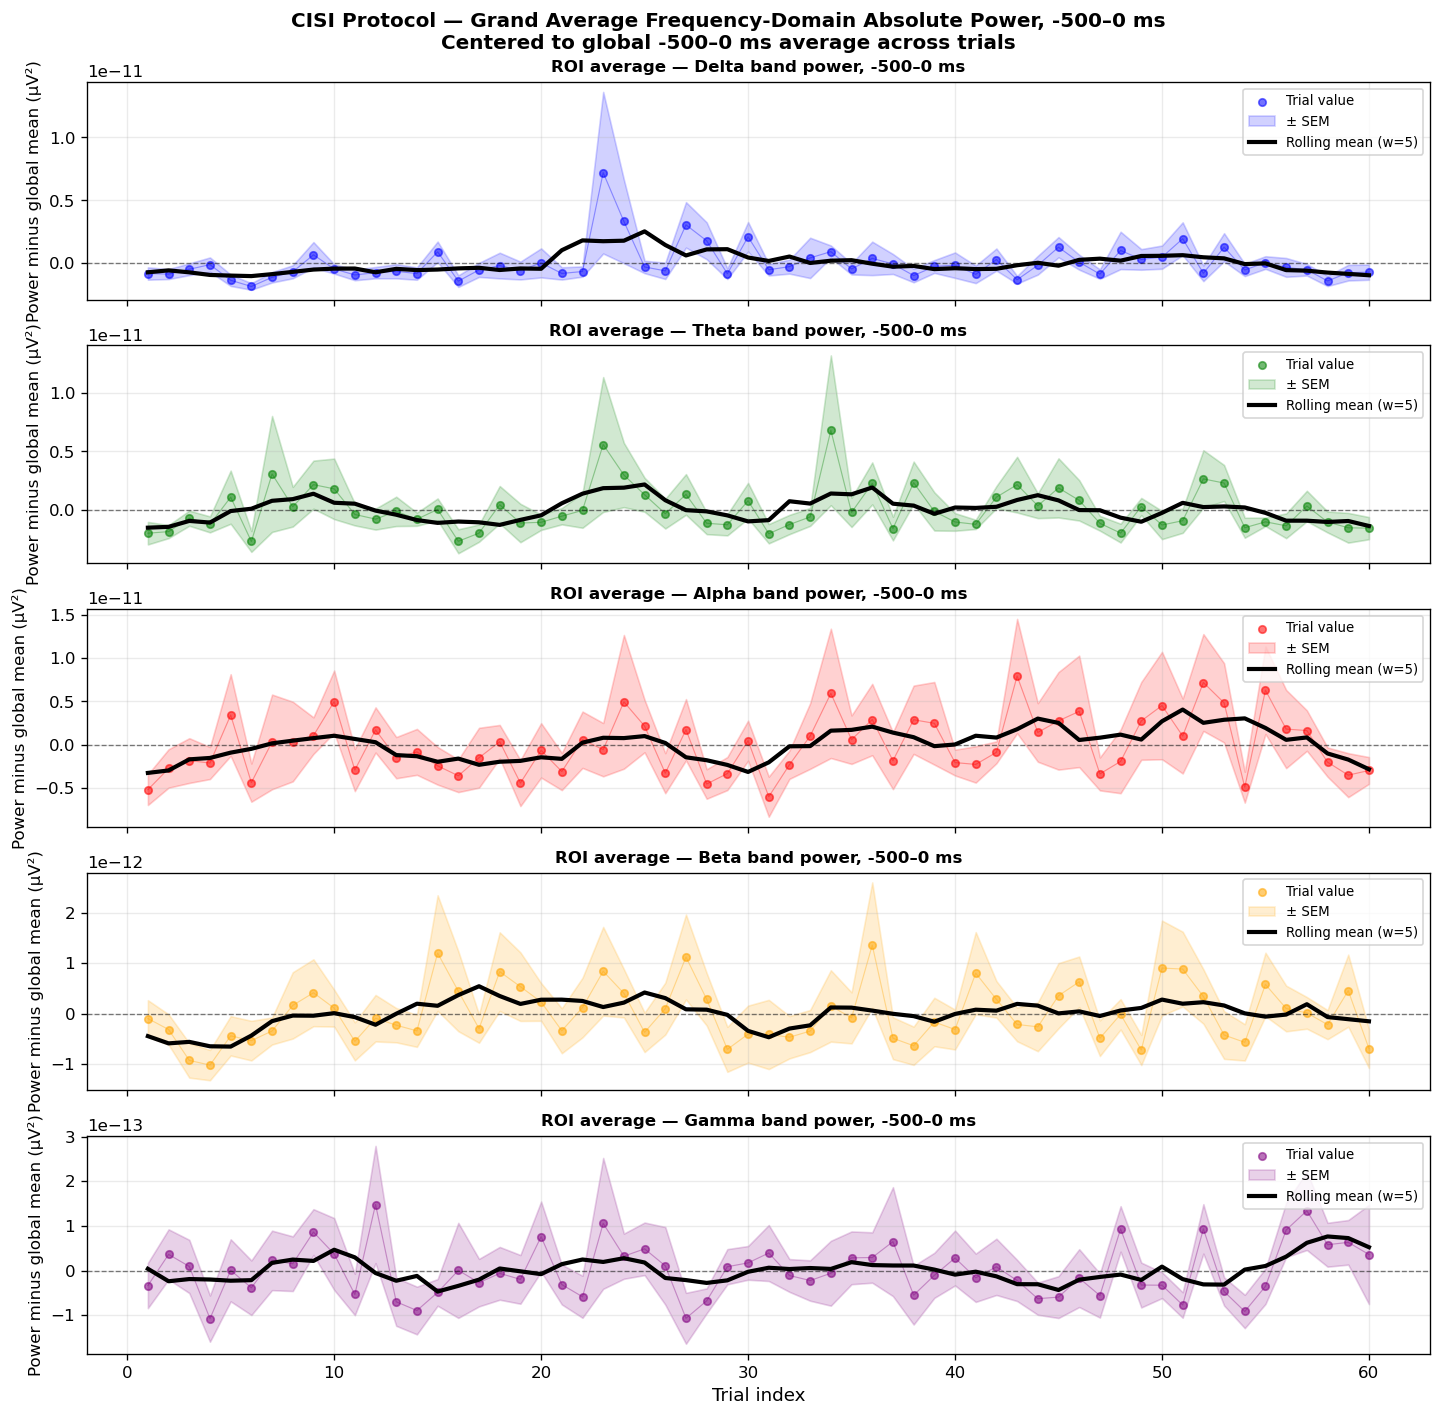

Figure saved: frequency_dynamics_CISI_neg500_0_global_mean_centered.png


In [10]:
# ------------------------------------------------------------
# FREQUENCY-DOMAIN ABSOLUTE POWER (-500–0 ms)
# centered to a subject-level global mean within the -500–0 ms window
# ------------------------------------------------------------

# These dictionaries store the -500–0 ms frequency-domain outputs.
all_power_pivots_raw_neg500_0 = {}
all_global_baseline_pivots_neg500_0 = {}
all_power_pivots_centered_neg500_0 = {}
all_psds_dicts_neg500_0 = {}

processed_subjects_neg500_0 = []
failed_subjects_neg500_0 = []

# Loop over subjects one at a time.
for subject_id in SUBJECTS:
    try:
        # Silence extra warnings and printouts.
        with warnings.catch_warnings():
            warnings.simplefilter("ignore")
            with contextlib.redirect_stdout(io.StringIO()), contextlib.redirect_stderr(io.StringIO()):

                # Load the epoched CISI data for this subject.
                epochs = load_eeg_data(
                    CONDITION,
                    subject_id,
                    channels=CHANNELS,
                    freq_band="delta_gamma"
                )

                # Crop the epochs to the pre-stimulus time window we want.
                # MNE uses seconds, so:
                #   -500 ms = -0.5 seconds
                #   0 ms    = 0.0 seconds
                epochs_neg500_0 = epochs.copy().crop(tmin=-0.5, tmax=0.0)

                # Compute frequency-domain absolute power using only -500–0 ms.
                # This uses the exact same helper function as the original graph.
                power_df, psds_dict = compute_frequency_power(epochs_neg500_0, fmin=0.5, fmax=45)

        # Convert long-format table into trial x band format.
        power_pivot_raw = (
            power_df.groupby(['trial', 'band'])['power']
            .mean()
            .unstack()
            .reindex(columns=bands)
        )

        # Compute this subject's global baseline for the -500–0 ms window.
        # This is the average power across all trials, separately for each band.
        global_baseline = power_pivot_raw.mean(axis=0)

        # Save the baseline as a one-row table.
        global_baseline_pivot = pd.DataFrame([global_baseline], columns=bands)

        # Center each trial by subtracting that subject's band-wise global mean.
        power_pivot_centered = power_pivot_raw - global_baseline

        # Store everything.
        all_power_pivots_raw_neg500_0[subject_id] = power_pivot_raw
        all_global_baseline_pivots_neg500_0[subject_id] = global_baseline_pivot
        all_power_pivots_centered_neg500_0[subject_id] = power_pivot_centered
        all_psds_dicts_neg500_0[subject_id] = psds_dict

        processed_subjects_neg500_0.append(subject_id)

    except Exception as e:
        failed_subjects_neg500_0.append((subject_id, str(e)))

print("-500–0 ms frequency-domain absolute-power subjects processed:", processed_subjects_neg500_0)

if failed_subjects_neg500_0:
    print("\n-500–0 ms frequency-domain absolute-power failures:")
    for subject_id, err in failed_subjects_neg500_0:
        print(f"Subject {subject_id}: {err}")


# ------------------------------------------------------------
# GRAND AVERAGE ABSOLUTE POWER ACROSS SUBJECTS
# ------------------------------------------------------------

grand_power_neg500_0 = {}
grand_sem_neg500_0 = {}

for band in bands:
    band_trials = []

    for subject_id in processed_subjects_neg500_0:
        power_pivot = all_power_pivots_centered_neg500_0[subject_id]

        if band in power_pivot.columns:
            band_trials.append(power_pivot[band].reset_index(drop=True))

    if band_trials:
        band_df = pd.concat(band_trials, axis=1)

        # Mean across subjects for each trial index.
        grand_power_neg500_0[band] = band_df.mean(axis=1)

        # SEM across subjects for each trial index.
        grand_sem_neg500_0[band] = band_df.std(axis=1) / np.sqrt(band_df.shape[1])


# ------------------------------------------------------------
# PLOT ABSOLUTE POWER, -500–0 ms
# ------------------------------------------------------------

fig, axes = plt.subplots(len(bands), 1, figsize=(12, 12), sharex=True)

for i, (band, color) in enumerate(zip(bands, colors)):
    ax = axes[i]

    if band in grand_power_neg500_0:
        values = grand_power_neg500_0[band].values
        errors = grand_sem_neg500_0[band].values
        trial_idx = np.arange(1, len(values) + 1)

        ax.scatter(
            trial_idx,
            values,
            color=color,
            s=20,
            alpha=0.55,
            zorder=2,
            label='Trial value'
        )

        ax.plot(
            trial_idx,
            values,
            color=color,
            linewidth=0.7,
            alpha=0.35,
            zorder=1
        )

        ax.fill_between(
            trial_idx,
            values - errors,
            values + errors,
            color=color,
            alpha=0.18,
            zorder=1,
            label='± SEM'
        )

        rolling = pd.Series(values).rolling(
            window=ROLLING_WINDOW,
            center=True,
            min_periods=1
        ).mean()

        ax.plot(
            trial_idx,
            rolling,
            color='black',
            linewidth=2.5,
            zorder=3,
            label=f'Rolling mean (w={ROLLING_WINDOW})'
        )

    ax.set_ylabel('Power minus global mean (µV²)', fontsize=10)

    ax.set_title(
        f'ROI average — {band.capitalize()} band power, -500–0 ms',
        fontsize=10,
        fontweight='bold'
    )

    ax.axhline(0, color='black', linewidth=0.8, linestyle='--', alpha=0.5)
    ax.legend(loc='upper right', fontsize=8)
    ax.grid(True, alpha=0.25)

axes[-1].set_xlabel('Trial index', fontsize=11)

fig.suptitle(
    'CISI Protocol — Grand Average Frequency-Domain Absolute Power, -500–0 ms\n'
    'Centered to global -500–0 ms average across trials',
    fontsize=12,
    fontweight='bold'
)

fig.tight_layout()
plt.savefig('frequency_dynamics_CISI_neg500_0_global_mean_centered.png', bbox_inches='tight', dpi=150)
plt.show()

print("Figure saved: frequency_dynamics_CISI_neg500_0_global_mean_centered.png")

0–500 ms frequency-domain absolute-power subjects processed: [2, 3, 5, 6, 7, 8, 9, 10, 11, 12, 13, 15, 16, 17]


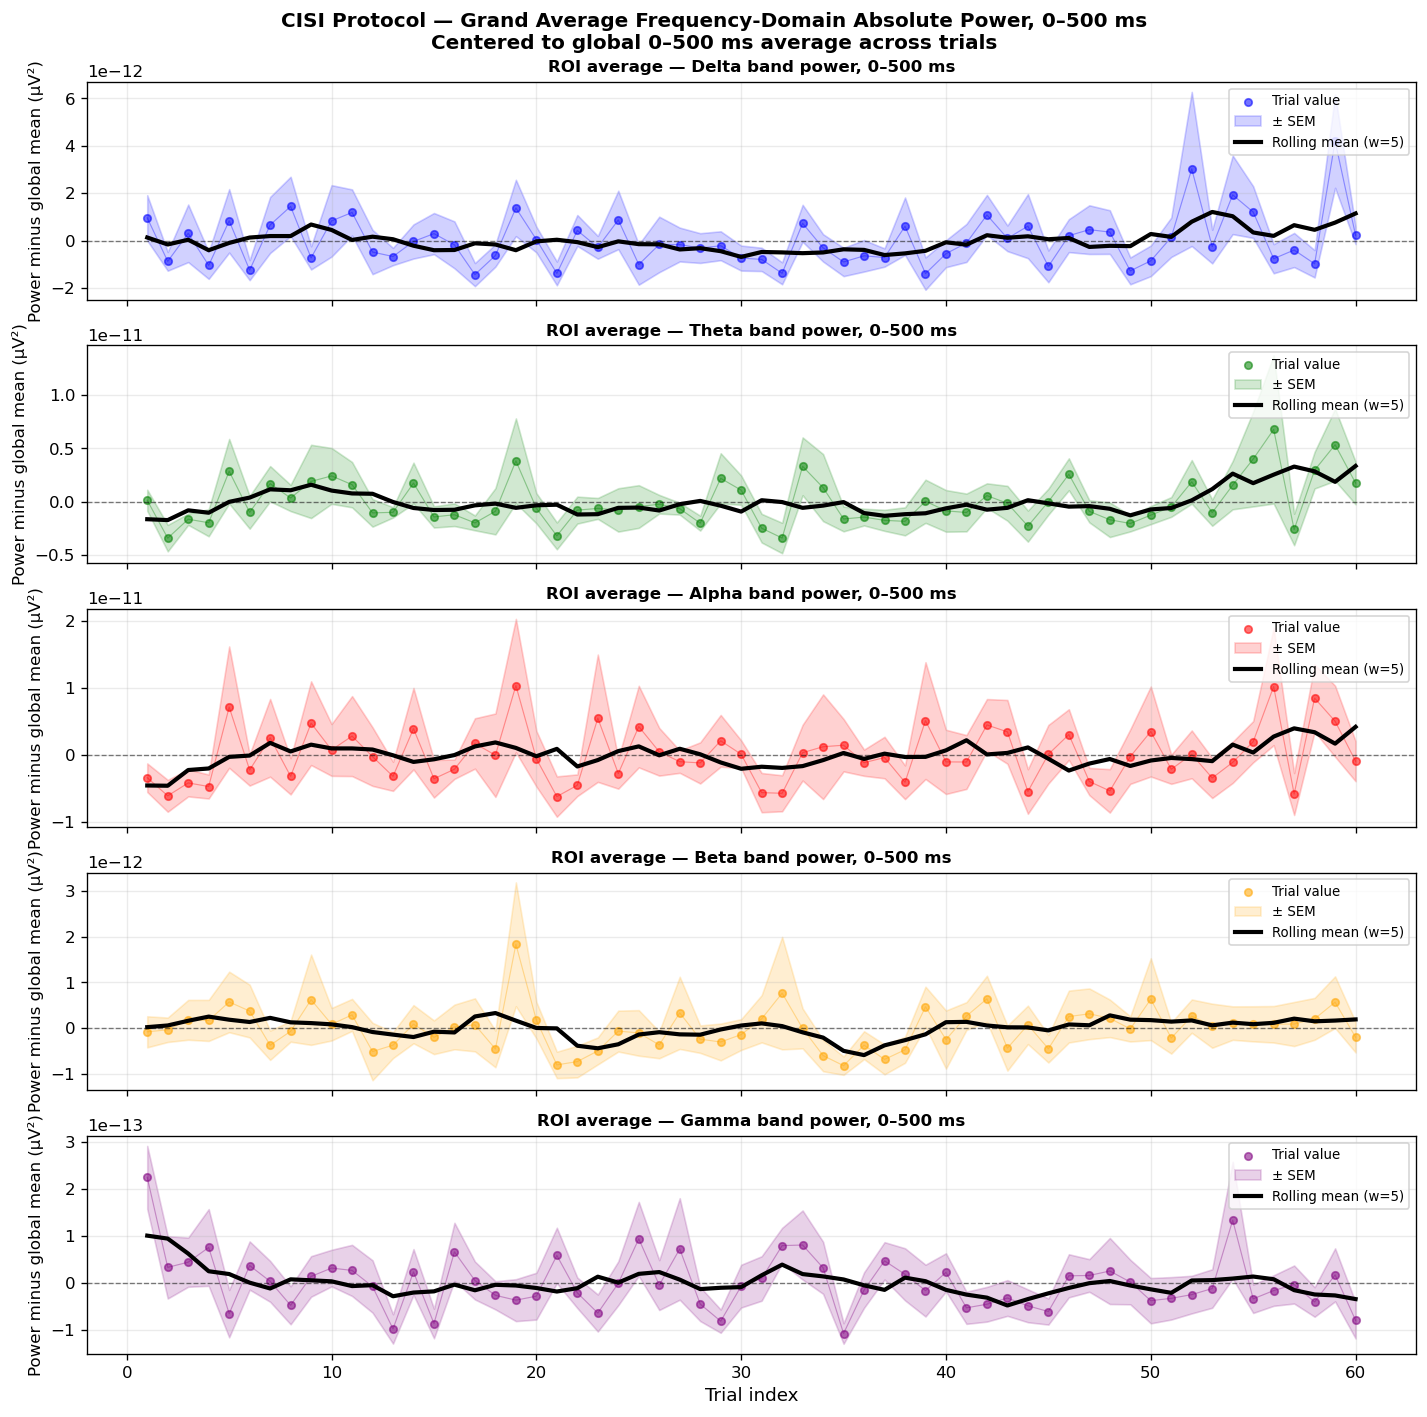

Figure saved: frequency_dynamics_CISI_0_500_global_mean_centered.png


In [11]:
# ------------------------------------------------------------
# FREQUENCY-DOMAIN ABSOLUTE POWER (0–500 ms)
# centered to a subject-level global mean within the 0–500 ms window
# ------------------------------------------------------------

# These dictionaries store the 0–500 ms frequency-domain outputs.
all_power_pivots_raw_0_500 = {}
all_global_baseline_pivots_0_500 = {}
all_power_pivots_centered_0_500 = {}
all_psds_dicts_0_500 = {}

processed_subjects_0_500 = []
failed_subjects_0_500 = []

# Loop over subjects one at a time.
for subject_id in SUBJECTS:
    try:
        # Silence extra warnings and printouts.
        with warnings.catch_warnings():
            warnings.simplefilter("ignore")
            with contextlib.redirect_stdout(io.StringIO()), contextlib.redirect_stderr(io.StringIO()):

                # Load the epoched CISI data for this subject.
                epochs = load_eeg_data(
                    CONDITION,
                    subject_id,
                    channels=CHANNELS,
                    freq_band="delta_gamma"
                )

                # Crop the epochs to the post-stimulus time window we want.
                # MNE uses seconds, so:
                #   0 ms   = 0.0 seconds
                #   500 ms = 0.5 seconds
                epochs_0_500 = epochs.copy().crop(tmin=0.0, tmax=0.5)

                # Compute frequency-domain absolute power using only 0–500 ms.
                # This uses the exact same helper function as the original graph.
                power_df, psds_dict = compute_frequency_power(epochs_0_500, fmin=0.5, fmax=45)

        # Convert long-format table into trial x band format.
        power_pivot_raw = (
            power_df.groupby(['trial', 'band'])['power']
            .mean()
            .unstack()
            .reindex(columns=bands)
        )

        # Compute this subject's global baseline for the 0–500 ms window.
        # This is the average power across all trials, separately for each band.
        global_baseline = power_pivot_raw.mean(axis=0)

        # Save the baseline as a one-row table.
        global_baseline_pivot = pd.DataFrame([global_baseline], columns=bands)

        # Center each trial by subtracting that subject's band-wise global mean.
        power_pivot_centered = power_pivot_raw - global_baseline

        # Store everything.
        all_power_pivots_raw_0_500[subject_id] = power_pivot_raw
        all_global_baseline_pivots_0_500[subject_id] = global_baseline_pivot
        all_power_pivots_centered_0_500[subject_id] = power_pivot_centered
        all_psds_dicts_0_500[subject_id] = psds_dict

        processed_subjects_0_500.append(subject_id)

    except Exception as e:
        failed_subjects_0_500.append((subject_id, str(e)))

print("0–500 ms frequency-domain absolute-power subjects processed:", processed_subjects_0_500)

if failed_subjects_0_500:
    print("\n0–500 ms frequency-domain absolute-power failures:")
    for subject_id, err in failed_subjects_0_500:
        print(f"Subject {subject_id}: {err}")


# ------------------------------------------------------------
# GRAND AVERAGE ABSOLUTE POWER ACROSS SUBJECTS
# ------------------------------------------------------------

grand_power_0_500 = {}
grand_sem_0_500 = {}

for band in bands:
    band_trials = []

    for subject_id in processed_subjects_0_500:
        power_pivot = all_power_pivots_centered_0_500[subject_id]

        if band in power_pivot.columns:
            band_trials.append(power_pivot[band].reset_index(drop=True))

    if band_trials:
        band_df = pd.concat(band_trials, axis=1)

        # Mean across subjects for each trial index.
        grand_power_0_500[band] = band_df.mean(axis=1)

        # SEM across subjects for each trial index.
        grand_sem_0_500[band] = band_df.std(axis=1) / np.sqrt(band_df.shape[1])


# ------------------------------------------------------------
# PLOT ABSOLUTE POWER, 0–500 ms
# ------------------------------------------------------------

fig, axes = plt.subplots(len(bands), 1, figsize=(12, 12), sharex=True)

for i, (band, color) in enumerate(zip(bands, colors)):
    ax = axes[i]

    if band in grand_power_0_500:
        values = grand_power_0_500[band].values
        errors = grand_sem_0_500[band].values
        trial_idx = np.arange(1, len(values) + 1)

        ax.scatter(
            trial_idx,
            values,
            color=color,
            s=20,
            alpha=0.55,
            zorder=2,
            label='Trial value'
        )

        ax.plot(
            trial_idx,
            values,
            color=color,
            linewidth=0.7,
            alpha=0.35,
            zorder=1
        )

        ax.fill_between(
            trial_idx,
            values - errors,
            values + errors,
            color=color,
            alpha=0.18,
            zorder=1,
            label='± SEM'
        )

        rolling = pd.Series(values).rolling(
            window=ROLLING_WINDOW,
            center=True,
            min_periods=1
        ).mean()

        ax.plot(
            trial_idx,
            rolling,
            color='black',
            linewidth=2.5,
            zorder=3,
            label=f'Rolling mean (w={ROLLING_WINDOW})'
        )

    ax.set_ylabel('Power minus global mean (µV²)', fontsize=10)

    ax.set_title(
        f'ROI average — {band.capitalize()} band power, 0–500 ms',
        fontsize=10,
        fontweight='bold'
    )

    ax.axhline(0, color='black', linewidth=0.8, linestyle='--', alpha=0.5)
    ax.legend(loc='upper right', fontsize=8)
    ax.grid(True, alpha=0.25)

axes[-1].set_xlabel('Trial index', fontsize=11)

fig.suptitle(
    'CISI Protocol — Grand Average Frequency-Domain Absolute Power, 0–500 ms\n'
    'Centered to global 0–500 ms average across trials',
    fontsize=12,
    fontweight='bold'
)

fig.tight_layout()
plt.savefig('frequency_dynamics_CISI_0_500_global_mean_centered.png', bbox_inches='tight', dpi=150)
plt.show()

print("Figure saved: frequency_dynamics_CISI_0_500_global_mean_centered.png")

500–1000 ms frequency-domain absolute-power subjects processed: [2, 3, 5, 6, 7, 8, 9, 10, 11, 12, 13, 15, 16, 17]


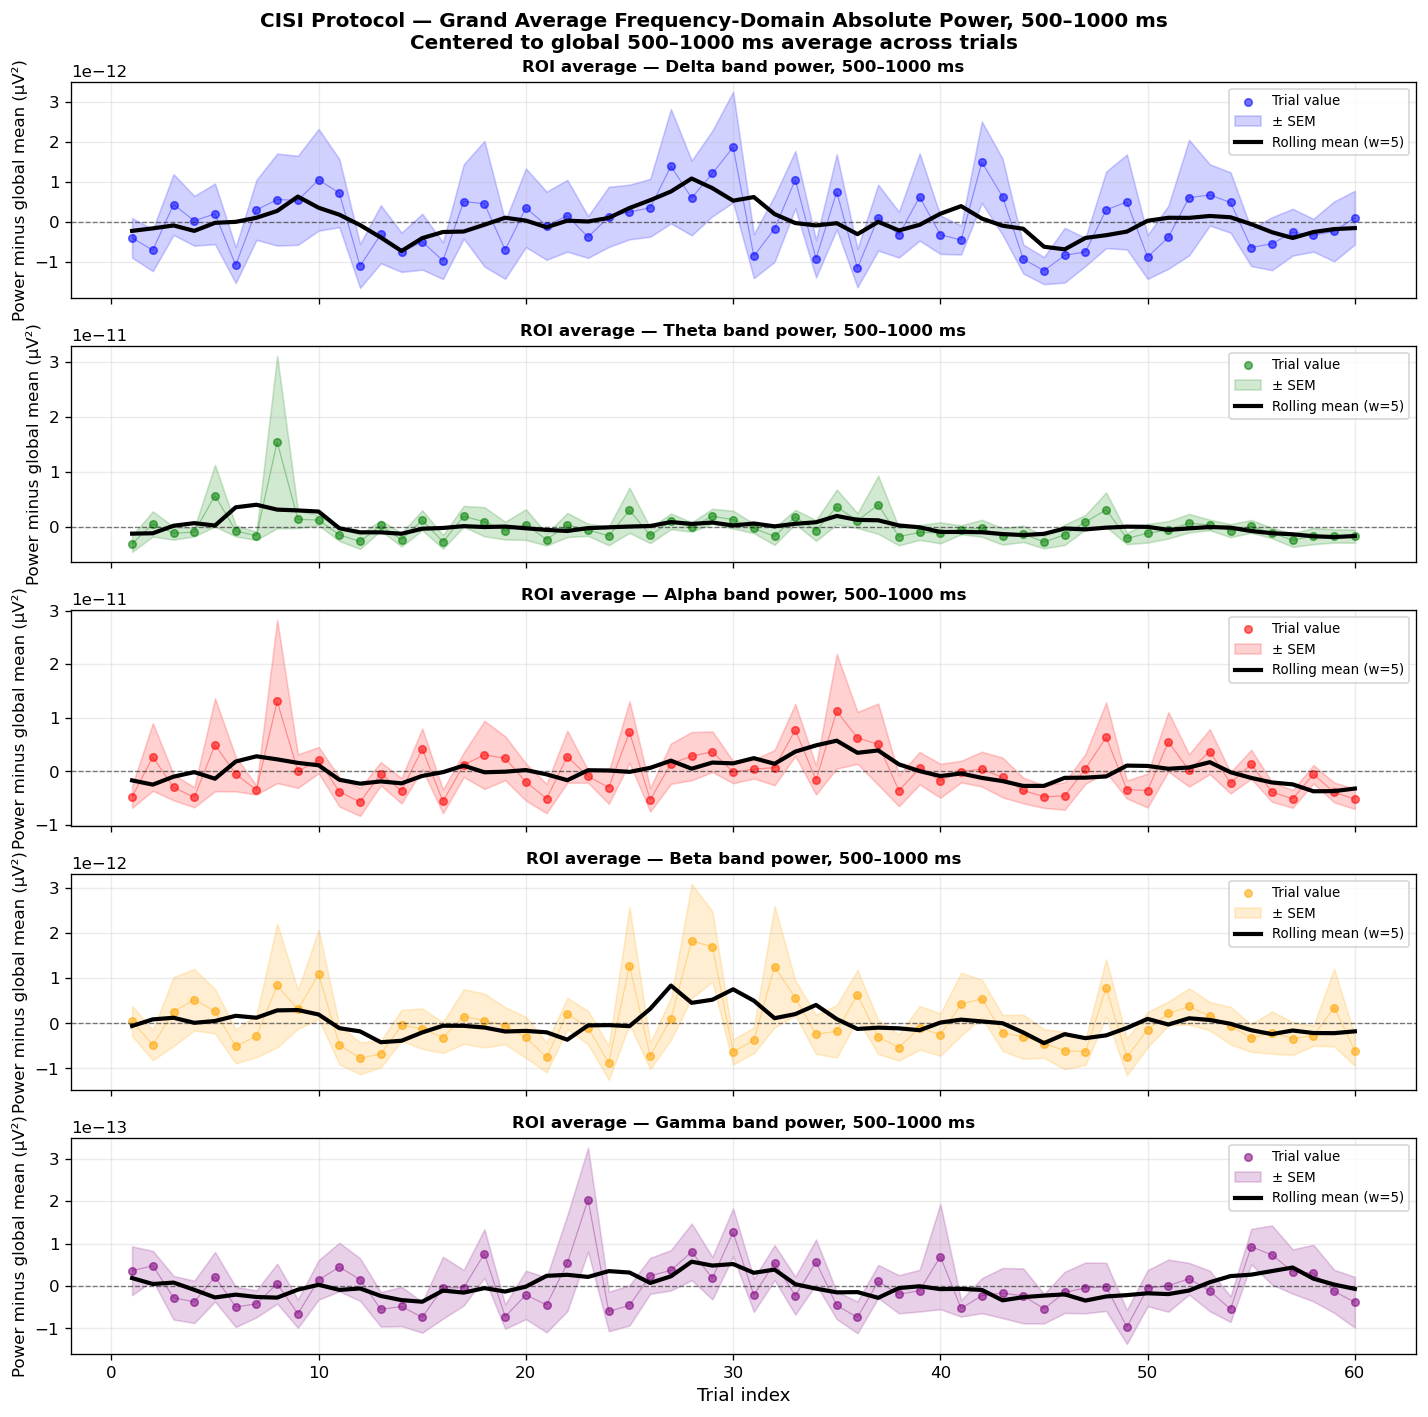

Figure saved: frequency_dynamics_CISI_500_1000_global_mean_centered.png


In [12]:
# ------------------------------------------------------------
# FREQUENCY-DOMAIN ABSOLUTE POWER (500–1000 ms)
# centered to a subject-level global mean within the 500–1000 ms window
# ------------------------------------------------------------

all_power_pivots_raw_500_1000 = {}
all_global_baseline_pivots_500_1000 = {}
all_power_pivots_centered_500_1000 = {}
all_psds_dicts_500_1000 = {}

processed_subjects_500_1000 = []
failed_subjects_500_1000 = []

for subject_id in SUBJECTS:
    try:
        with warnings.catch_warnings():
            warnings.simplefilter("ignore")
            with contextlib.redirect_stdout(io.StringIO()), contextlib.redirect_stderr(io.StringIO()):

                epochs = load_eeg_data(
                    CONDITION,
                    subject_id,
                    channels=CHANNELS,
                    freq_band="delta_gamma"
                )

                # Crop to 500–1000 ms after stimulus onset.
                epochs_500_1000 = epochs.copy().crop(tmin=0.5, tmax=1.0)

                # Compute frequency-domain absolute power using only 500–1000 ms.
                power_df, psds_dict = compute_frequency_power(
                    epochs_500_1000,
                    fmin=0.5,
                    fmax=45
                )

        # Convert long-format power table into trial x band format.
        power_pivot_raw = (
            power_df.groupby(['trial', 'band'])['power']
            .mean()
            .unstack()
            .reindex(columns=bands)
        )

        # Compute this subject's global mean power for this window.
        global_baseline = power_pivot_raw.mean(axis=0)

        # Center each trial by subtracting this subject's band-wise global mean.
        power_pivot_centered = power_pivot_raw - global_baseline

        # Store subject-level results.
        all_power_pivots_raw_500_1000[subject_id] = power_pivot_raw
        all_global_baseline_pivots_500_1000[subject_id] = pd.DataFrame([global_baseline], columns=bands)
        all_power_pivots_centered_500_1000[subject_id] = power_pivot_centered
        all_psds_dicts_500_1000[subject_id] = psds_dict

        processed_subjects_500_1000.append(subject_id)

    except Exception as e:
        failed_subjects_500_1000.append((subject_id, str(e)))

print("500–1000 ms frequency-domain absolute-power subjects processed:", processed_subjects_500_1000)

if failed_subjects_500_1000:
    print("\n500–1000 ms frequency-domain absolute-power failures:")
    for subject_id, err in failed_subjects_500_1000:
        print(f"Subject {subject_id}: {err}")


# Grand average across subjects.
grand_power_500_1000 = {}
grand_sem_500_1000 = {}

for band in bands:
    band_trials = []

    for subject_id in processed_subjects_500_1000:
        power_pivot = all_power_pivots_centered_500_1000[subject_id]

        if band in power_pivot.columns:
            band_trials.append(power_pivot[band].reset_index(drop=True))

    if band_trials:
        band_df = pd.concat(band_trials, axis=1)

        grand_power_500_1000[band] = band_df.mean(axis=1)
        grand_sem_500_1000[band] = band_df.std(axis=1) / np.sqrt(band_df.shape[1])


# Plot absolute power.
fig, axes = plt.subplots(len(bands), 1, figsize=(12, 12), sharex=True)

for i, (band, color) in enumerate(zip(bands, colors)):
    ax = axes[i]

    if band in grand_power_500_1000:
        values = grand_power_500_1000[band].values
        errors = grand_sem_500_1000[band].values
        trial_idx = np.arange(1, len(values) + 1)

        ax.scatter(
            trial_idx,
            values,
            color=color,
            s=20,
            alpha=0.55,
            zorder=2,
            label='Trial value'
        )

        ax.plot(
            trial_idx,
            values,
            color=color,
            linewidth=0.7,
            alpha=0.35,
            zorder=1
        )

        ax.fill_between(
            trial_idx,
            values - errors,
            values + errors,
            color=color,
            alpha=0.18,
            zorder=1,
            label='± SEM'
        )

        rolling = pd.Series(values).rolling(
            window=ROLLING_WINDOW,
            center=True,
            min_periods=1
        ).mean()

        ax.plot(
            trial_idx,
            rolling,
            color='black',
            linewidth=2.5,
            zorder=3,
            label=f'Rolling mean (w={ROLLING_WINDOW})'
        )

    ax.set_ylabel('Power minus global mean (µV²)', fontsize=10)

    ax.set_title(
        f'ROI average — {band.capitalize()} band power, 500–1000 ms',
        fontsize=10,
        fontweight='bold'
    )

    ax.axhline(0, color='black', linewidth=0.8, linestyle='--', alpha=0.5)
    ax.legend(loc='upper right', fontsize=8)
    ax.grid(True, alpha=0.25)

axes[-1].set_xlabel('Trial index', fontsize=11)

fig.suptitle(
    'CISI Protocol — Grand Average Frequency-Domain Absolute Power, 500–1000 ms\n'
    'Centered to global 500–1000 ms average across trials',
    fontsize=12,
    fontweight='bold'
)

fig.tight_layout()
plt.savefig('frequency_dynamics_CISI_500_1000_global_mean_centered.png', bbox_inches='tight', dpi=150)
plt.show()

print("Figure saved: frequency_dynamics_CISI_500_1000_global_mean_centered.png")

# Add-on sections: the other graph types using the same global-baseline idea

Everything below follows the same logic as the first section of this notebook:

1. Compute the **raw** quantity first  
2. For each **subject** and **band**, compute one **global baseline**
3. Subtract that same baseline everywhere within that subject and band
4. Grand-average the centered values across subjects

The only difference is **what** raw quantity is being centered:
- relative frequency-domain power
- absolute time-frequency power
- relative time-frequency power
- filtered vs. unfiltered frequency-domain absolute power


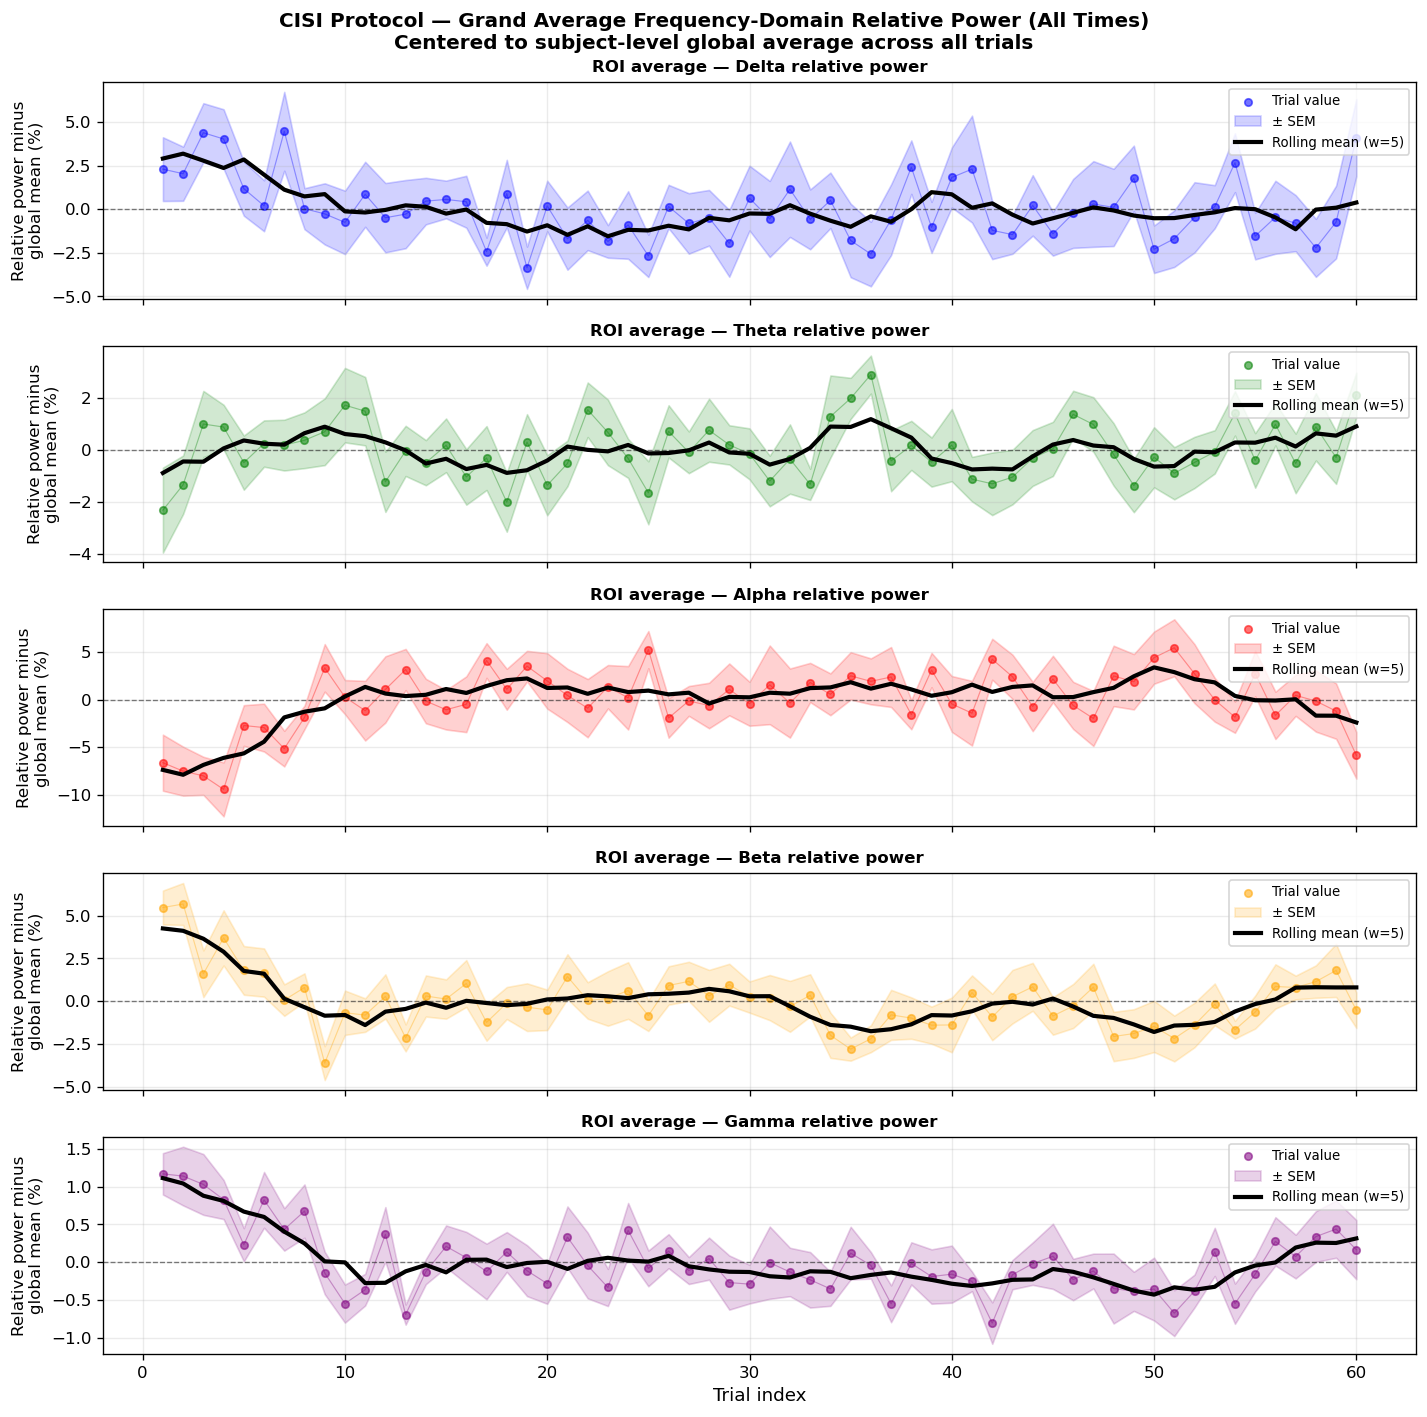

Figure saved: frequency_relative_dynamics_CISI_global_mean_centered.png


In [13]:
# ------------------------------------------------------------
# FREQUENCY-DOMAIN RELATIVE POWER (all times)
# centered to a subject-level global relative-power mean
# ------------------------------------------------------------

# These dictionaries will store, for each subject:
# 1) the raw relative power for each trial and band
# 2) the one-row global baseline that gets subtracted
# 3) the centered relative power after subtracting that baseline
all_relative_power_pivots_raw = {}
all_relative_global_baseline_pivots = {}
all_relative_power_pivots_centered = {}

# Loop over each subject that already successfully completed
# the raw frequency-domain absolute-power section above.
for subject_id in processed_subjects:

    # Start from the raw absolute power table:
    # rows = trials
    # columns = bands
    power_pivot_raw = all_power_pivots_raw[subject_id].copy()

    # Force the same band order for every subject so later
    # averaging lines up delta with delta, alpha with alpha, etc.
    power_pivot_raw = power_pivot_raw.reindex(columns=bands)

    # For each trial, total power is the sum across all bands.
    # axis=1 means sum across columns within each row.
    total_power_per_trial = power_pivot_raw.sum(axis=1)

    # Convert absolute power into relative power:
    # each band becomes its percentage of that trial's total power.
    relative_power_raw = power_pivot_raw.div(total_power_per_trial, axis=0) * 100

    # Compute one subject-level global baseline for each band.
    # This is the mean relative power across all trials for that band.
    relative_global_baseline = relative_power_raw.mean(axis=0)

    # Save the baseline as a one-row DataFrame so you can inspect it later.
    relative_global_baseline_pivot = pd.DataFrame([relative_global_baseline], columns=bands)

    # Subtract the same baseline value from every trial in that band.
    # After this step:
    #   0  = equal to subject's average relative power for that band
    #   >0 = above average
    #   <0 = below average
    relative_power_centered = relative_power_raw - relative_global_baseline

    # Store everything.
    all_relative_power_pivots_raw[subject_id] = relative_power_raw
    all_relative_global_baseline_pivots[subject_id] = relative_global_baseline_pivot
    all_relative_power_pivots_centered[subject_id] = relative_power_centered

# These will hold the grand mean and SEM across subjects for each band.
grand_relative_power = {}
grand_relative_sem = {}

# Build one grand-average trial series per band.
for band in bands:

    # Collect one subject vector per band.
    band_trials = []

    for subject_id in processed_subjects:
        relative_pivot = all_relative_power_pivots_centered[subject_id]

        if band in relative_pivot.columns:
            # reset_index(drop=True) makes trial positions line up cleanly
            # when subjects are concatenated side by side.
            band_trials.append(relative_pivot[band].reset_index(drop=True))

    if band_trials:
        band_df = pd.concat(band_trials, axis=1)
        grand_relative_power[band] = band_df.mean(axis=1)
        grand_relative_sem[band] = band_df.std(axis=1) / np.sqrt(band_df.shape[1])

# Plot one subplot per band.
fig, axes = plt.subplots(len(bands), 1, figsize=(12, 12), sharex=True)

for i, (band, color) in enumerate(zip(bands, colors)):
    ax = axes[i]

    if band in grand_relative_power:
        values = grand_relative_power[band].values
        errors = grand_relative_sem[band].values
        trial_idx = np.arange(1, len(values) + 1)

        # Trial-by-trial grand mean
        ax.scatter(trial_idx, values, color=color, s=20, alpha=0.55, zorder=2, label='Trial value')
        ax.plot(trial_idx, values, color=color, linewidth=0.7, alpha=0.35, zorder=1)

        # Uncertainty shading
        ax.fill_between(
            trial_idx,
            values - errors,
            values + errors,
            color=color,
            alpha=0.18,
            zorder=1,
            label='± SEM'
        )

        # Rolling trend line to make the overall direction easier to see
        rolling = pd.Series(values).rolling(
            window=ROLLING_WINDOW,
            center=True,
            min_periods=1
        ).mean()

        ax.plot(
            trial_idx,
            rolling,
            color='black',
            linewidth=2.5,
            zorder=3,
            label=f'Rolling mean (w={ROLLING_WINDOW})'
        )

    ax.set_ylabel('Relative power minus\nglobal mean (%)', fontsize=10)
    ax.set_title(f'ROI average — {band.capitalize()} relative power', fontsize=10, fontweight='bold')
    ax.axhline(0, color='black', linewidth=0.8, linestyle='--', alpha=0.5)
    ax.grid(True, alpha=0.25)
    ax.legend(loc='upper right', fontsize=8)

axes[-1].set_xlabel('Trial index', fontsize=11)

fig.suptitle(
    'CISI Protocol — Grand Average Frequency-Domain Relative Power (All Times)\n'
    'Centered to subject-level global average across all trials',
    fontsize=12,
    fontweight='bold'
)

fig.tight_layout()
plt.savefig('frequency_relative_dynamics_CISI_global_mean_centered.png', bbox_inches='tight', dpi=150)
plt.show()

print("Figure saved: frequency_relative_dynamics_CISI_global_mean_centered.png")


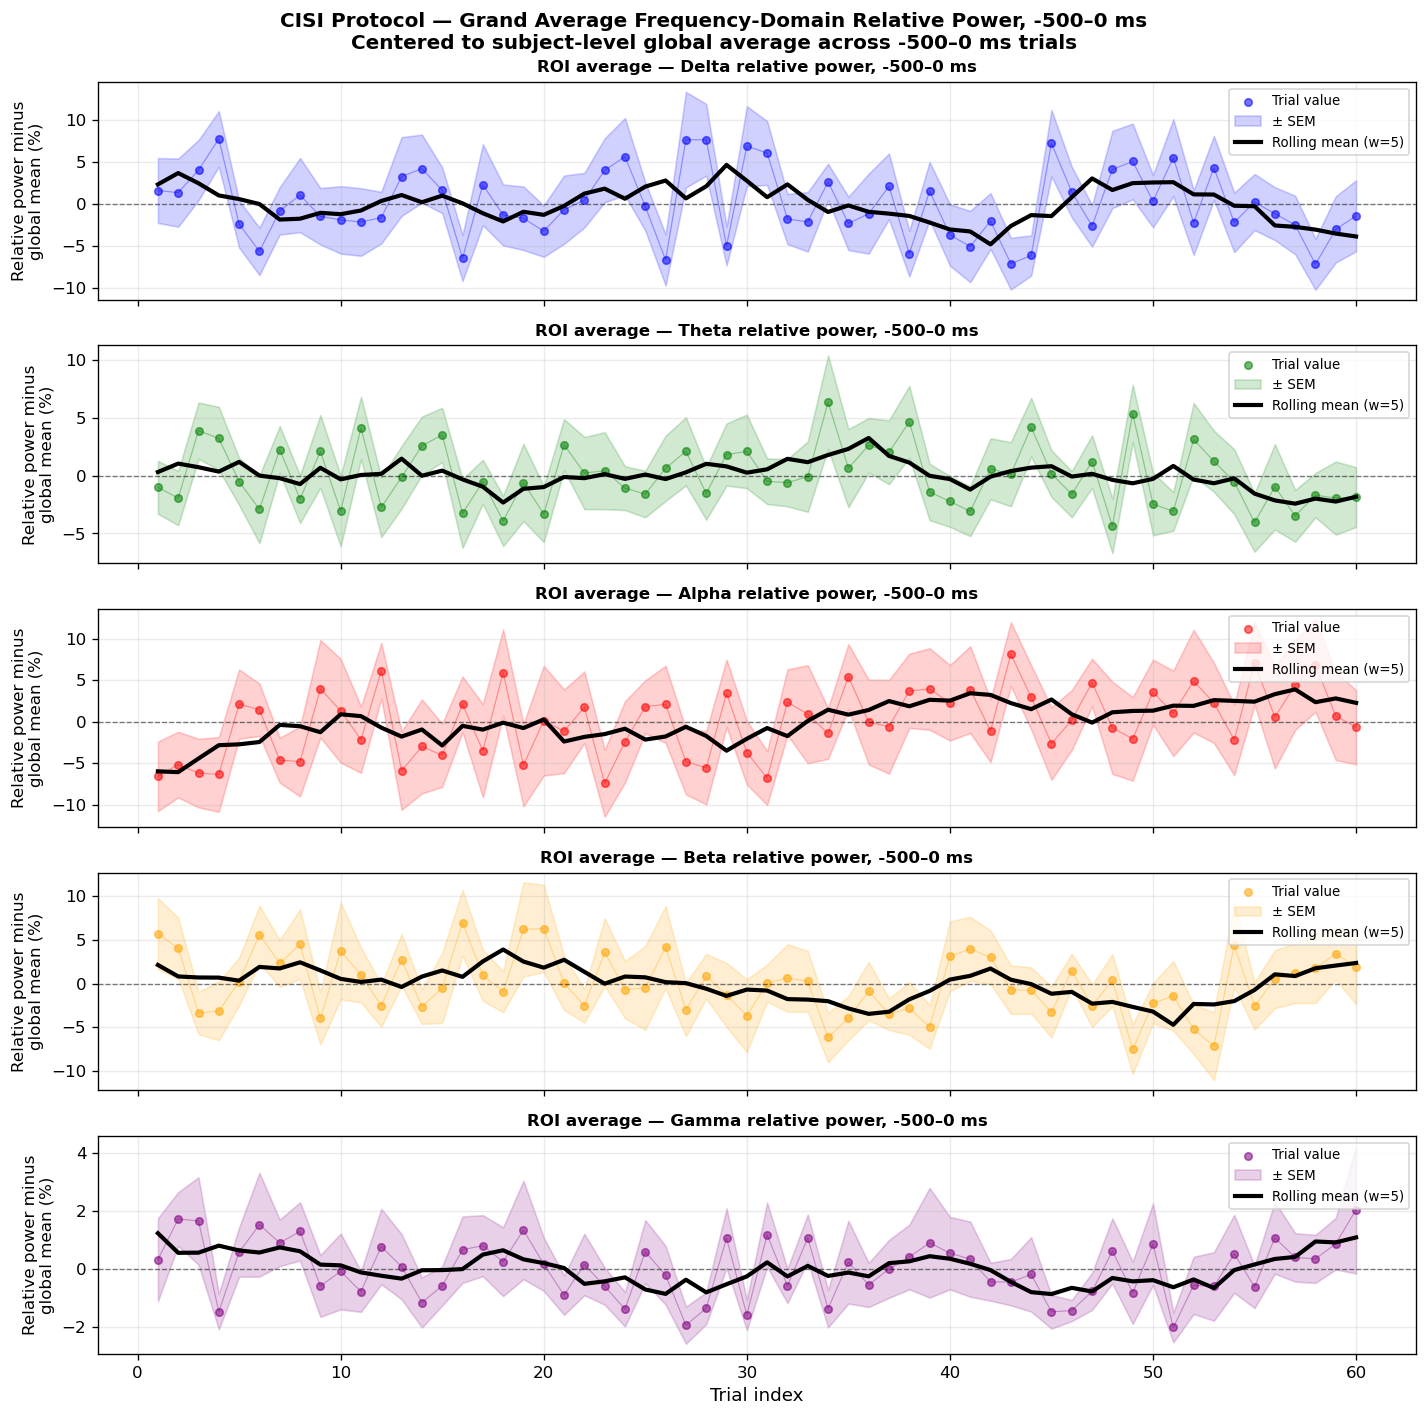

Figure saved: frequency_relative_dynamics_CISI_neg500_0_global_mean_centered.png


In [14]:
# ------------------------------------------------------------
# FREQUENCY-DOMAIN RELATIVE POWER (-500–0 ms)
# centered to a subject-level global relative-power mean
# ------------------------------------------------------------

all_relative_power_pivots_raw_neg500_0 = {}
all_relative_global_baseline_pivots_neg500_0 = {}
all_relative_power_pivots_centered_neg500_0 = {}

for subject_id in processed_subjects_neg500_0:

    # Start from the raw -500–0 ms absolute power table.
    power_pivot_raw = all_power_pivots_raw_neg500_0[subject_id].copy()

    # Keep the same band order.
    power_pivot_raw = power_pivot_raw.reindex(columns=bands)

    # Total power per trial across all bands.
    total_power_per_trial = power_pivot_raw.sum(axis=1)

    # Convert absolute power to relative power.
    relative_power_raw = power_pivot_raw.div(total_power_per_trial, axis=0) * 100

    # Compute this subject's global relative-power baseline for -500–0 ms.
    relative_global_baseline = relative_power_raw.mean(axis=0)

    # Save as a one-row table.
    relative_global_baseline_pivot = pd.DataFrame([relative_global_baseline], columns=bands)

    # Center each trial by subtracting the subject's band-wise relative-power mean.
    relative_power_centered = relative_power_raw - relative_global_baseline

    # Store everything.
    all_relative_power_pivots_raw_neg500_0[subject_id] = relative_power_raw
    all_relative_global_baseline_pivots_neg500_0[subject_id] = relative_global_baseline_pivot
    all_relative_power_pivots_centered_neg500_0[subject_id] = relative_power_centered


# ------------------------------------------------------------
# GRAND AVERAGE RELATIVE POWER ACROSS SUBJECTS
# ------------------------------------------------------------

grand_relative_power_neg500_0 = {}
grand_relative_sem_neg500_0 = {}

for band in bands:
    band_trials = []

    for subject_id in processed_subjects_neg500_0:
        relative_pivot = all_relative_power_pivots_centered_neg500_0[subject_id]

        if band in relative_pivot.columns:
            band_trials.append(relative_pivot[band].reset_index(drop=True))

    if band_trials:
        band_df = pd.concat(band_trials, axis=1)
        grand_relative_power_neg500_0[band] = band_df.mean(axis=1)
        grand_relative_sem_neg500_0[band] = band_df.std(axis=1) / np.sqrt(band_df.shape[1])


# ------------------------------------------------------------
# PLOT RELATIVE POWER, -500–0 ms
# ------------------------------------------------------------

fig, axes = plt.subplots(len(bands), 1, figsize=(12, 12), sharex=True)

for i, (band, color) in enumerate(zip(bands, colors)):
    ax = axes[i]

    if band in grand_relative_power_neg500_0:
        values = grand_relative_power_neg500_0[band].values
        errors = grand_relative_sem_neg500_0[band].values
        trial_idx = np.arange(1, len(values) + 1)

        ax.scatter(
            trial_idx,
            values,
            color=color,
            s=20,
            alpha=0.55,
            zorder=2,
            label='Trial value'
        )

        ax.plot(
            trial_idx,
            values,
            color=color,
            linewidth=0.7,
            alpha=0.35,
            zorder=1
        )

        ax.fill_between(
            trial_idx,
            values - errors,
            values + errors,
            color=color,
            alpha=0.18,
            zorder=1,
            label='± SEM'
        )

        rolling = pd.Series(values).rolling(
            window=ROLLING_WINDOW,
            center=True,
            min_periods=1
        ).mean()

        ax.plot(
            trial_idx,
            rolling,
            color='black',
            linewidth=2.5,
            zorder=3,
            label=f'Rolling mean (w={ROLLING_WINDOW})'
        )

    ax.set_ylabel('Relative power minus\nglobal mean (%)', fontsize=10)

    ax.set_title(
        f'ROI average — {band.capitalize()} relative power, -500–0 ms',
        fontsize=10,
        fontweight='bold'
    )

    ax.axhline(0, color='black', linewidth=0.8, linestyle='--', alpha=0.5)
    ax.grid(True, alpha=0.25)
    ax.legend(loc='upper right', fontsize=8)

axes[-1].set_xlabel('Trial index', fontsize=11)

fig.suptitle(
    'CISI Protocol — Grand Average Frequency-Domain Relative Power, -500–0 ms\n'
    'Centered to subject-level global average across -500–0 ms trials',
    fontsize=12,
    fontweight='bold'
)

fig.tight_layout()
plt.savefig('frequency_relative_dynamics_CISI_neg500_0_global_mean_centered.png', bbox_inches='tight', dpi=150)
plt.show()

print("Figure saved: frequency_relative_dynamics_CISI_neg500_0_global_mean_centered.png")

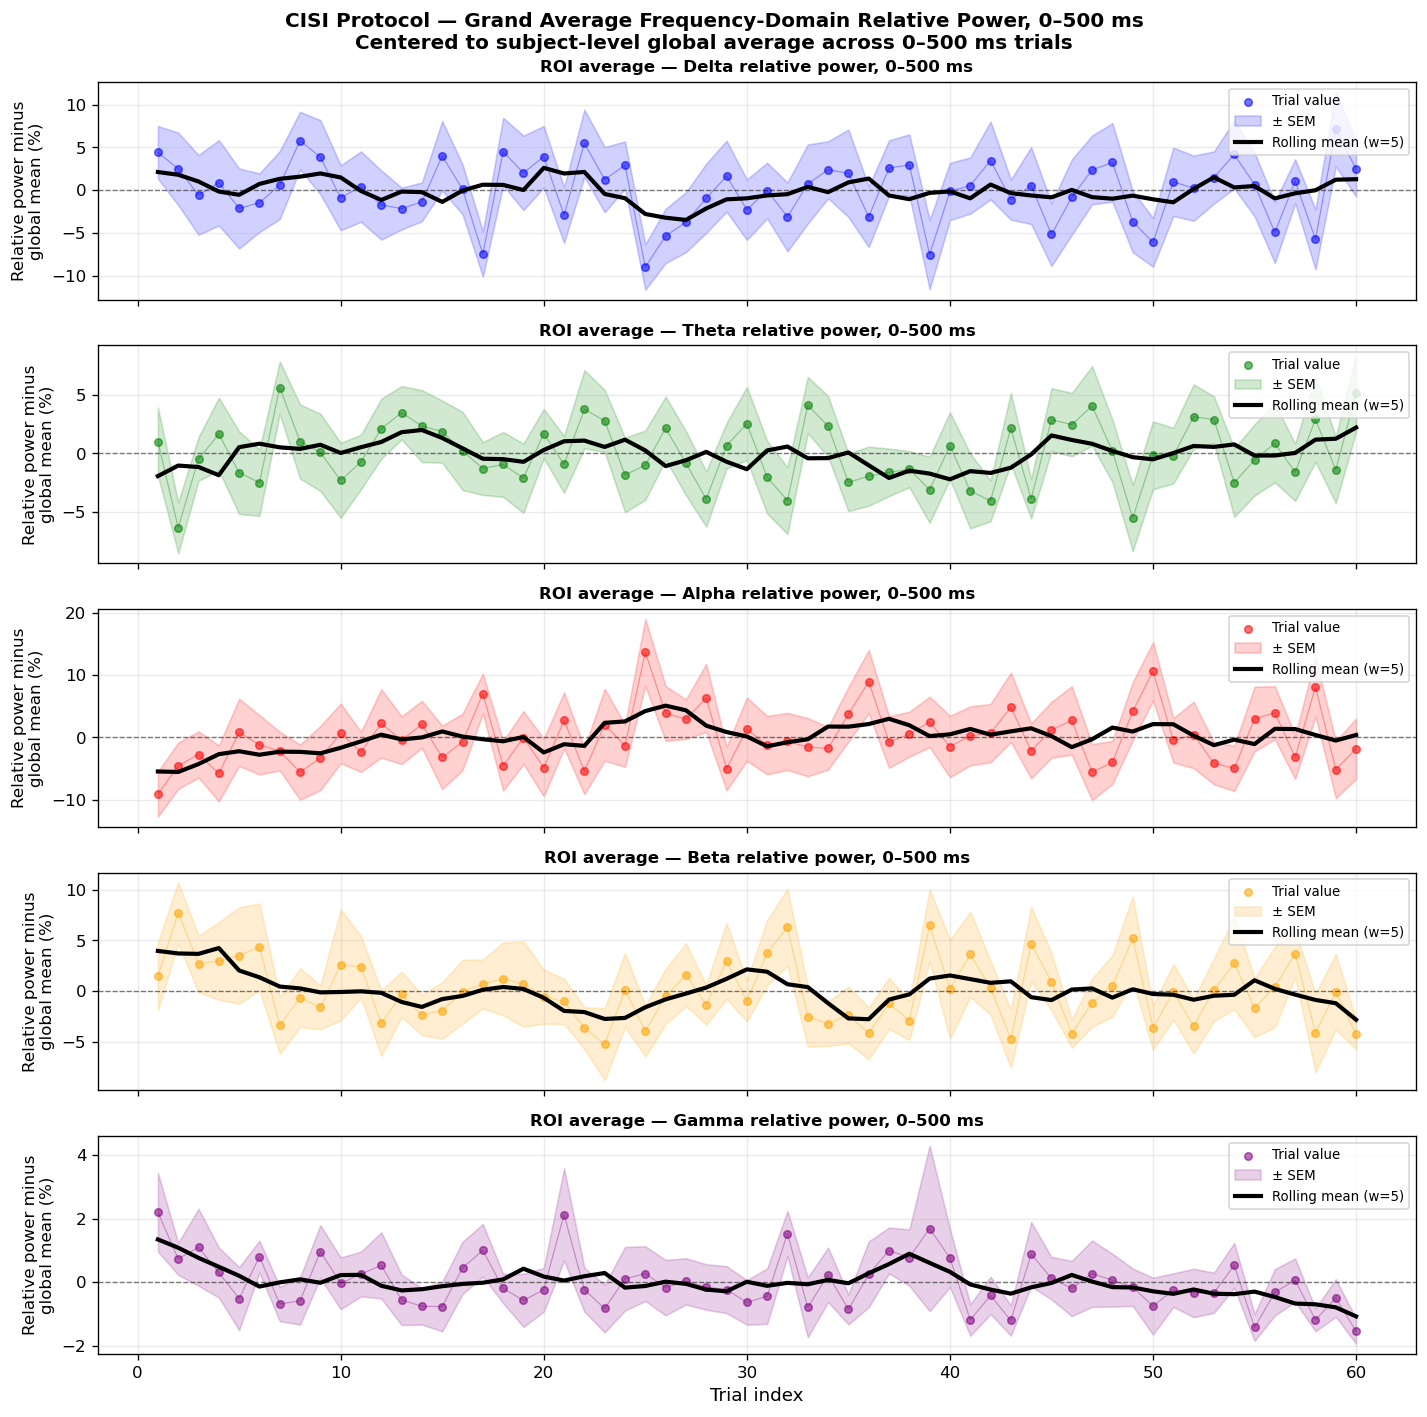

Figure saved: frequency_relative_dynamics_CISI_0_500_global_mean_centered.png


In [15]:
# ------------------------------------------------------------
# FREQUENCY-DOMAIN RELATIVE POWER (0–500 ms)
# centered to a subject-level global relative-power mean
# ------------------------------------------------------------

all_relative_power_pivots_raw_0_500 = {}
all_relative_global_baseline_pivots_0_500 = {}
all_relative_power_pivots_centered_0_500 = {}

for subject_id in processed_subjects_0_500:

    # Start from the raw 0–500 ms absolute power table.
    power_pivot_raw = all_power_pivots_raw_0_500[subject_id].copy()

    # Keep the same band order.
    power_pivot_raw = power_pivot_raw.reindex(columns=bands)

    # Total power per trial across all bands.
    total_power_per_trial = power_pivot_raw.sum(axis=1)

    # Convert absolute power to relative power.
    relative_power_raw = power_pivot_raw.div(total_power_per_trial, axis=0) * 100

    # Compute this subject's global relative-power baseline for 0–500 ms.
    relative_global_baseline = relative_power_raw.mean(axis=0)

    # Save as a one-row table.
    relative_global_baseline_pivot = pd.DataFrame([relative_global_baseline], columns=bands)

    # Center each trial by subtracting the subject's band-wise relative-power mean.
    relative_power_centered = relative_power_raw - relative_global_baseline

    # Store everything.
    all_relative_power_pivots_raw_0_500[subject_id] = relative_power_raw
    all_relative_global_baseline_pivots_0_500[subject_id] = relative_global_baseline_pivot
    all_relative_power_pivots_centered_0_500[subject_id] = relative_power_centered


# ------------------------------------------------------------
# GRAND AVERAGE RELATIVE POWER ACROSS SUBJECTS
# ------------------------------------------------------------

grand_relative_power_0_500 = {}
grand_relative_sem_0_500 = {}

for band in bands:
    band_trials = []

    for subject_id in processed_subjects_0_500:
        relative_pivot = all_relative_power_pivots_centered_0_500[subject_id]

        if band in relative_pivot.columns:
            band_trials.append(relative_pivot[band].reset_index(drop=True))

    if band_trials:
        band_df = pd.concat(band_trials, axis=1)
        grand_relative_power_0_500[band] = band_df.mean(axis=1)
        grand_relative_sem_0_500[band] = band_df.std(axis=1) / np.sqrt(band_df.shape[1])


# ------------------------------------------------------------
# PLOT RELATIVE POWER, 0–500 ms
# ------------------------------------------------------------

fig, axes = plt.subplots(len(bands), 1, figsize=(12, 12), sharex=True)

for i, (band, color) in enumerate(zip(bands, colors)):
    ax = axes[i]

    if band in grand_relative_power_0_500:
        values = grand_relative_power_0_500[band].values
        errors = grand_relative_sem_0_500[band].values
        trial_idx = np.arange(1, len(values) + 1)

        ax.scatter(
            trial_idx,
            values,
            color=color,
            s=20,
            alpha=0.55,
            zorder=2,
            label='Trial value'
        )

        ax.plot(
            trial_idx,
            values,
            color=color,
            linewidth=0.7,
            alpha=0.35,
            zorder=1
        )

        ax.fill_between(
            trial_idx,
            values - errors,
            values + errors,
            color=color,
            alpha=0.18,
            zorder=1,
            label='± SEM'
        )

        rolling = pd.Series(values).rolling(
            window=ROLLING_WINDOW,
            center=True,
            min_periods=1
        ).mean()

        ax.plot(
            trial_idx,
            rolling,
            color='black',
            linewidth=2.5,
            zorder=3,
            label=f'Rolling mean (w={ROLLING_WINDOW})'
        )

    ax.set_ylabel('Relative power minus\nglobal mean (%)', fontsize=10)

    ax.set_title(
        f'ROI average — {band.capitalize()} relative power, 0–500 ms',
        fontsize=10,
        fontweight='bold'
    )

    ax.axhline(0, color='black', linewidth=0.8, linestyle='--', alpha=0.5)
    ax.grid(True, alpha=0.25)
    ax.legend(loc='upper right', fontsize=8)

axes[-1].set_xlabel('Trial index', fontsize=11)

fig.suptitle(
    'CISI Protocol — Grand Average Frequency-Domain Relative Power, 0–500 ms\n'
    'Centered to subject-level global average across 0–500 ms trials',
    fontsize=12,
    fontweight='bold'
)

fig.tight_layout()
plt.savefig('frequency_relative_dynamics_CISI_0_500_global_mean_centered.png', bbox_inches='tight', dpi=150)
plt.show()

print("Figure saved: frequency_relative_dynamics_CISI_0_500_global_mean_centered.png")

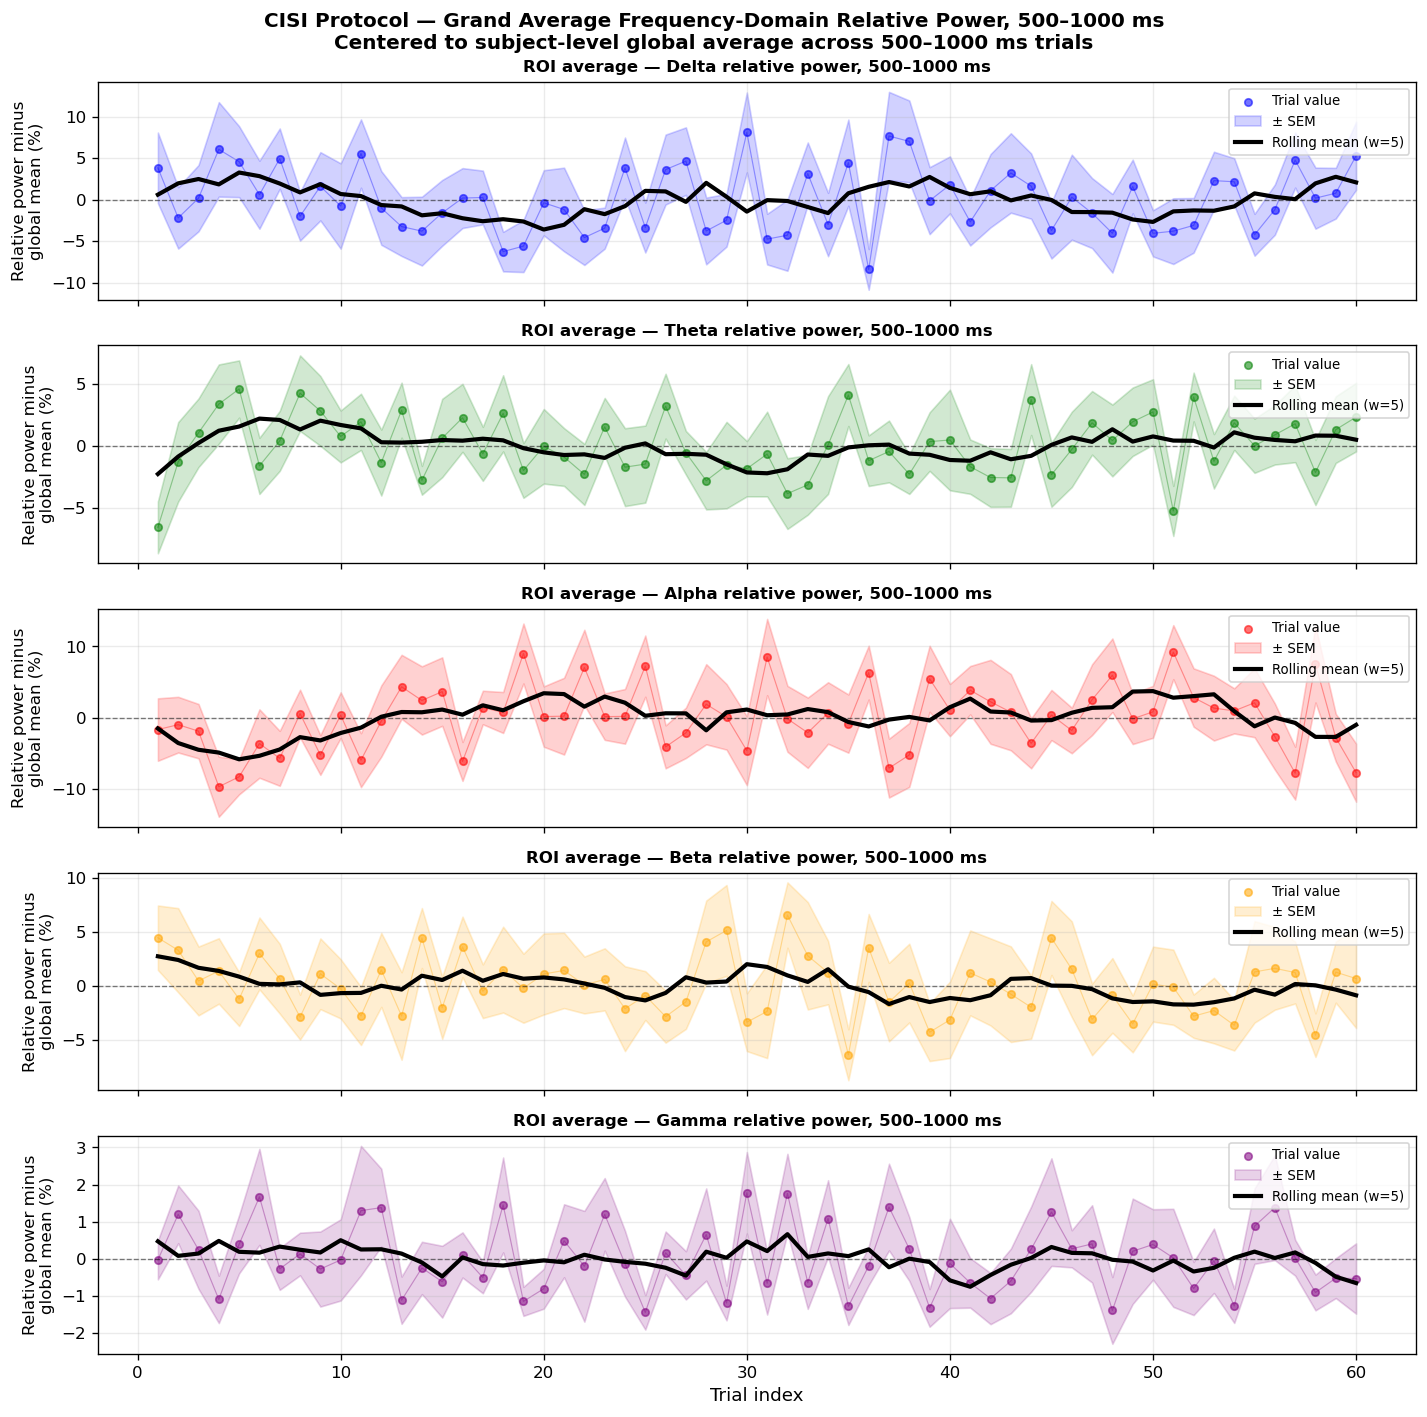

Figure saved: frequency_relative_dynamics_CISI_500_1000_global_mean_centered.png


In [16]:
# ------------------------------------------------------------
# FREQUENCY-DOMAIN RELATIVE POWER (500–1000 ms)
# centered to a subject-level global relative-power mean
# ------------------------------------------------------------

all_relative_power_pivots_raw_500_1000 = {}
all_relative_global_baseline_pivots_500_1000 = {}
all_relative_power_pivots_centered_500_1000 = {}

for subject_id in processed_subjects_500_1000:

    # Start from the raw 500–1000 ms absolute power table.
    power_pivot_raw = all_power_pivots_raw_500_1000[subject_id].copy()

    # Keep the same band order.
    power_pivot_raw = power_pivot_raw.reindex(columns=bands)

    # Total power per trial across all bands.
    total_power_per_trial = power_pivot_raw.sum(axis=1)

    # Convert absolute power to relative power.
    relative_power_raw = power_pivot_raw.div(total_power_per_trial, axis=0) * 100

    # Compute this subject's global relative-power mean for this window.
    relative_global_baseline = relative_power_raw.mean(axis=0)

    # Center each trial by subtracting that subject-level mean.
    relative_power_centered = relative_power_raw - relative_global_baseline

    # Store results.
    all_relative_power_pivots_raw_500_1000[subject_id] = relative_power_raw
    all_relative_global_baseline_pivots_500_1000[subject_id] = pd.DataFrame(
        [relative_global_baseline],
        columns=bands
    )
    all_relative_power_pivots_centered_500_1000[subject_id] = relative_power_centered


# Grand average across subjects.
grand_relative_power_500_1000 = {}
grand_relative_sem_500_1000 = {}

for band in bands:
    band_trials = []

    for subject_id in processed_subjects_500_1000:
        relative_pivot = all_relative_power_pivots_centered_500_1000[subject_id]

        if band in relative_pivot.columns:
            band_trials.append(relative_pivot[band].reset_index(drop=True))

    if band_trials:
        band_df = pd.concat(band_trials, axis=1)

        grand_relative_power_500_1000[band] = band_df.mean(axis=1)
        grand_relative_sem_500_1000[band] = band_df.std(axis=1) / np.sqrt(band_df.shape[1])


# Plot relative power.
fig, axes = plt.subplots(len(bands), 1, figsize=(12, 12), sharex=True)

for i, (band, color) in enumerate(zip(bands, colors)):
    ax = axes[i]

    if band in grand_relative_power_500_1000:
        values = grand_relative_power_500_1000[band].values
        errors = grand_relative_sem_500_1000[band].values
        trial_idx = np.arange(1, len(values) + 1)

        ax.scatter(
            trial_idx,
            values,
            color=color,
            s=20,
            alpha=0.55,
            zorder=2,
            label='Trial value'
        )

        ax.plot(
            trial_idx,
            values,
            color=color,
            linewidth=0.7,
            alpha=0.35,
            zorder=1
        )

        ax.fill_between(
            trial_idx,
            values - errors,
            values + errors,
            color=color,
            alpha=0.18,
            zorder=1,
            label='± SEM'
        )

        rolling = pd.Series(values).rolling(
            window=ROLLING_WINDOW,
            center=True,
            min_periods=1
        ).mean()

        ax.plot(
            trial_idx,
            rolling,
            color='black',
            linewidth=2.5,
            zorder=3,
            label=f'Rolling mean (w={ROLLING_WINDOW})'
        )

    ax.set_ylabel('Relative power minus\nglobal mean (%)', fontsize=10)

    ax.set_title(
        f'ROI average — {band.capitalize()} relative power, 500–1000 ms',
        fontsize=10,
        fontweight='bold'
    )

    ax.axhline(0, color='black', linewidth=0.8, linestyle='--', alpha=0.5)
    ax.grid(True, alpha=0.25)
    ax.legend(loc='upper right', fontsize=8)

axes[-1].set_xlabel('Trial index', fontsize=11)

fig.suptitle(
    'CISI Protocol — Grand Average Frequency-Domain Relative Power, 500–1000 ms\n'
    'Centered to subject-level global average across 500–1000 ms trials',
    fontsize=12,
    fontweight='bold'
)

fig.tight_layout()
plt.savefig('frequency_relative_dynamics_CISI_500_1000_global_mean_centered.png', bbox_inches='tight', dpi=150)
plt.show()

print("Figure saved: frequency_relative_dynamics_CISI_500_1000_global_mean_centered.png")

Time-frequency absolute-power subjects processed: [2, 3, 5, 6, 7, 8, 9, 10, 11, 12, 13, 15, 16, 17]


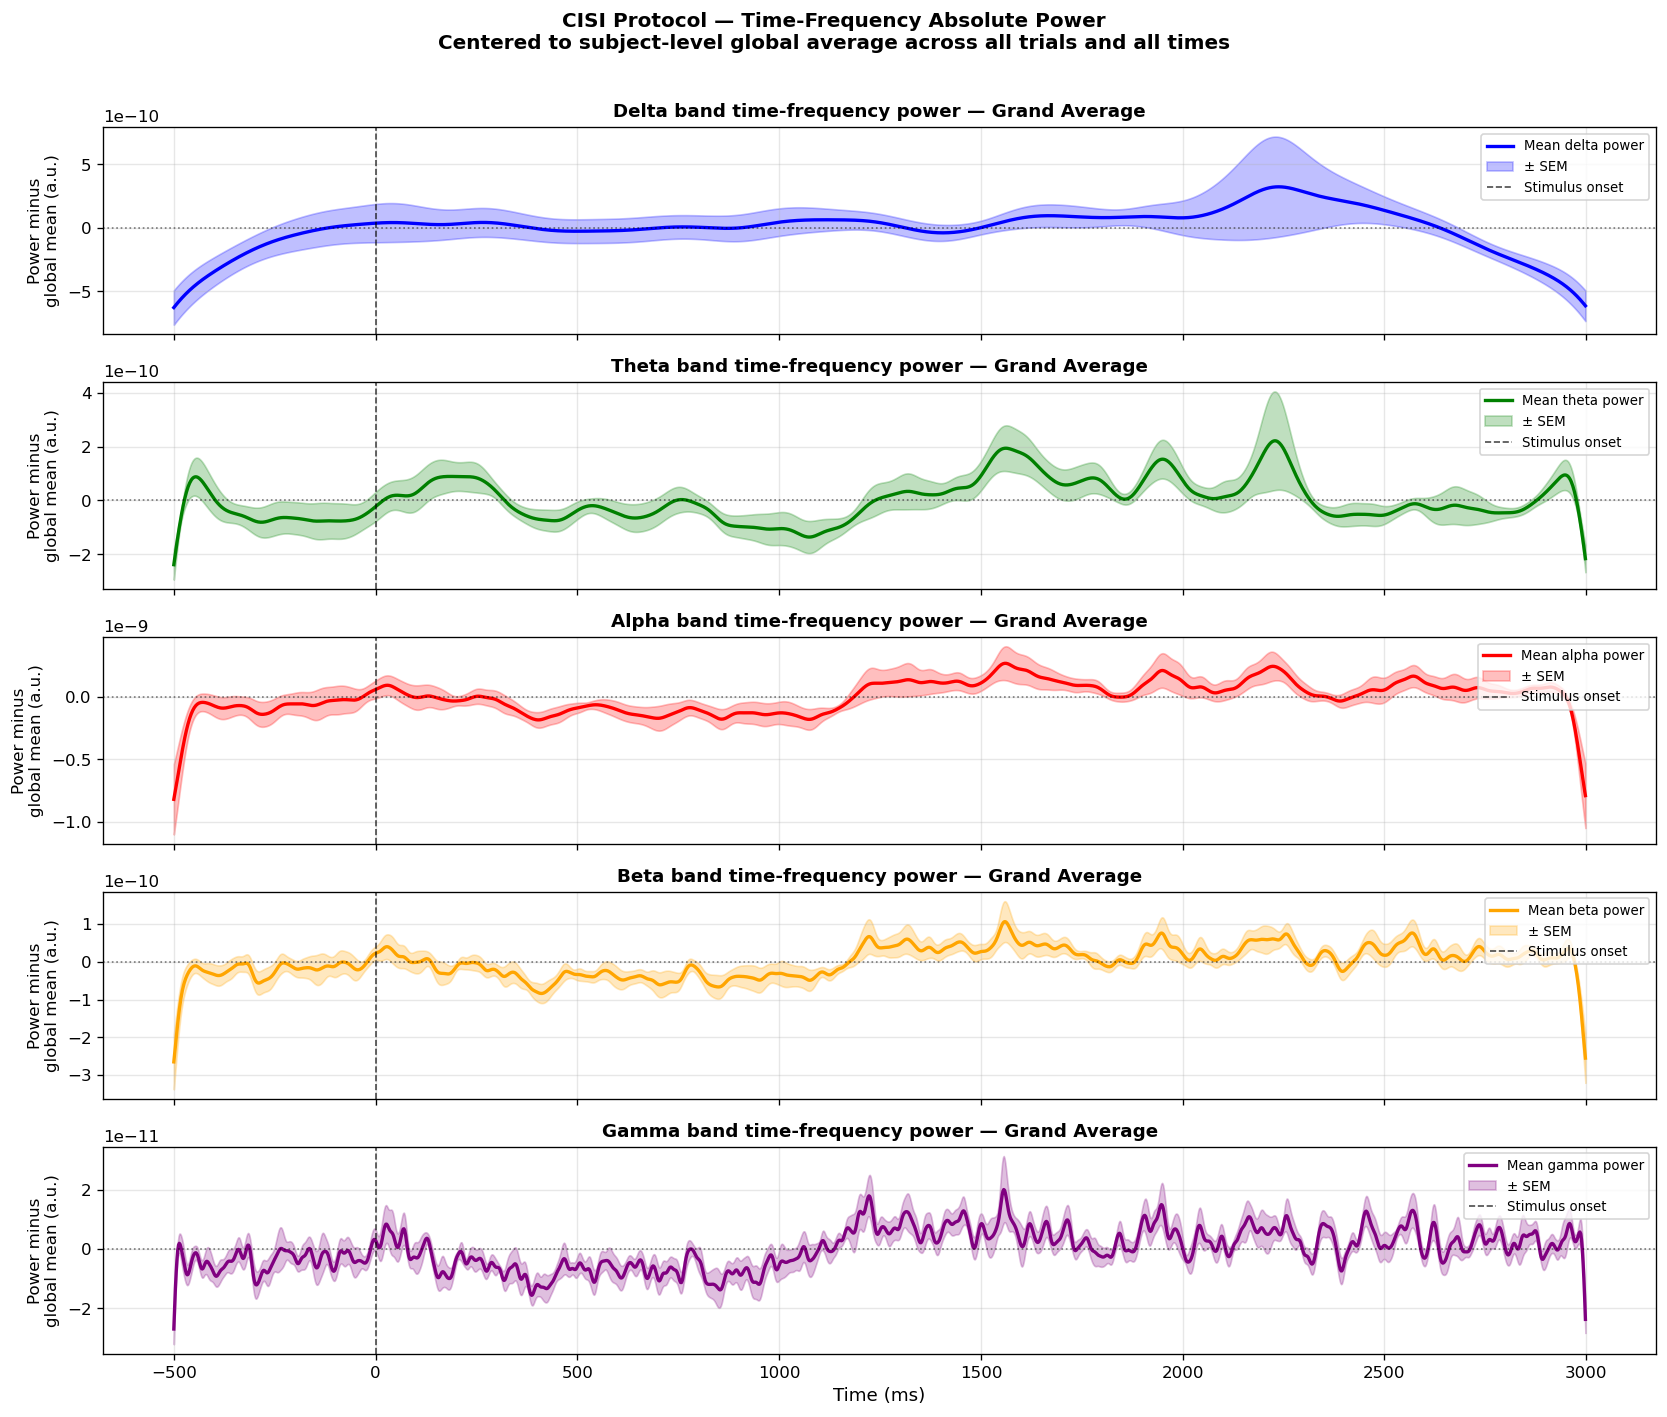

Figure saved: tf_absolute_power_CISI_global_mean_centered.png


In [17]:
# ------------------------------------------------------------
# TIME-FREQUENCY ABSOLUTE POWER (all times)
# centered to a subject-level global mean across all trials and all times
# ------------------------------------------------------------

# Import the wavelet function used to compute time-frequency power.
from mne.time_frequency import tfr_morlet

# Frequencies sampled by the time-frequency decomposition.
# Log spacing gives more detail at low frequencies where bands are narrower.
TF_FREQS = np.logspace(np.log10(1), np.log10(45), 20)

# Number of wavelet cycles controls the time-vs-frequency tradeoff.
TF_N_CYCLES = 2.0

# Frequency limits used to define the named bands.
band_limits = {
    'delta': (1, 4),
    'theta': (4, 8),
    'alpha': (8, 13),
    'beta': (13, 30),
    'gamma': (30, 45),
}

# These dictionaries will store, for each subject:
# - raw time-frequency band power (trial x time)
# - one scalar baseline per band
# - centered time-frequency band power after subtraction
tf_power_pivots_raw = {}
tf_global_baseline_pivots = {}
tf_power_pivots_centered = {}

# Track success/failure separately for this section.
tf_processed_subjects = []
tf_failed_subjects = []

for subject_id in SUBJECTS:
    try:
        with warnings.catch_warnings():
            warnings.simplefilter("ignore")
            with contextlib.redirect_stdout(io.StringIO()), contextlib.redirect_stderr(io.StringIO()):

                # Load the epochs for this subject.
                epochs = load_eeg_data(
                    CONDITION,
                    subject_id,
                    channels=CHANNELS,
                    freq_band="delta_gamma"
                )

                # Compute time-frequency power separately for each ROI channel.
                # average=False keeps individual trials instead of averaging them away.
                roi_channel_tfrs = []

                for ch in epochs.ch_names:
                    tfr = tfr_morlet(
                        epochs.copy().pick([ch]),
                        freqs=TF_FREQS,
                        n_cycles=TF_N_CYCLES,
                        average=False,
                        return_itc=False,
                        verbose=False
                    )

                    # tfr.data shape here is:
                    # (n_trials, 1 channel, n_freqs, n_times)
                    # Remove the singleton channel dimension.
                    roi_channel_tfrs.append(tfr.data[:, 0, :, :])

                # Average across the ROI channels so each subject ends up with
                # one trial x frequency x time array.
                roi_power = np.mean(roi_channel_tfrs, axis=0)

                # Time values corresponding to the last dimension of roi_power.
                time_points = tfr.times * 1000  # convert seconds to ms for plotting

                # Store raw and centered band-specific trial x time tables here.
                subject_raw_bands = {}
                subject_centered_bands = {}
                baseline_row = {}

                # Collapse the full frequency axis into the canonical named bands.
                for band in bands:
                    fmin, fmax = band_limits[band]

                    # Keep only the frequencies that fall inside this band.
                    freq_mask = (TF_FREQS >= fmin) & (TF_FREQS < fmax)

                    if not np.any(freq_mask):
                        continue

                    # Average across the selected frequencies.
                    # Result shape: (n_trials, n_times)
                    band_power_raw = roi_power[:, freq_mask, :].mean(axis=1)

                    # Convert to a DataFrame:
                    # rows = trials
                    # columns = time points in ms
                    band_power_raw_df = pd.DataFrame(band_power_raw, columns=time_points)

                    # One scalar global baseline for this subject and band:
                    # mean over every trial and every time point.
                    band_global_baseline = band_power_raw_df.values.mean()

                    # Subtract that same scalar from the full trial x time map.
                    band_power_centered_df = band_power_raw_df - band_global_baseline

                    subject_raw_bands[band] = band_power_raw_df
                    subject_centered_bands[band] = band_power_centered_df
                    baseline_row[band] = band_global_baseline

        tf_power_pivots_raw[subject_id] = subject_raw_bands
        tf_power_pivots_centered[subject_id] = subject_centered_bands
        tf_global_baseline_pivots[subject_id] = pd.DataFrame([baseline_row], columns=bands)

        tf_processed_subjects.append(subject_id)

    except Exception as e:
        tf_failed_subjects.append((subject_id, str(e)))

print("Time-frequency absolute-power subjects processed:", tf_processed_subjects)

if tf_failed_subjects:
    print("\nTime-frequency absolute-power failures:")
    for subject_id, err in tf_failed_subjects:
        print(f"Subject {subject_id}: {err}")

# Grand-average across subjects for each band at each time point.
grand_tf_power = {}
grand_tf_sem = {}

for band in bands:
    band_subject_means = []

    for subject_id in tf_processed_subjects:
        tf_pivot = tf_power_pivots_centered[subject_id]

        if band in tf_pivot:
            # Mean over trials for this subject, leaving time on the x-axis.
            subject_mean = tf_pivot[band].mean(axis=0)
            band_subject_means.append(subject_mean.reset_index(drop=True))

    if band_subject_means:
        band_df = pd.concat(band_subject_means, axis=1)
        grand_tf_power[band] = band_df.mean(axis=1)
        grand_tf_sem[band] = band_df.std(axis=1) / np.sqrt(band_df.shape[1])

# Get time points from the first available subject/band.
first_subject = tf_processed_subjects[0]
first_band = next(b for b in bands if b in tf_power_pivots_centered[first_subject])
time_points = tf_power_pivots_centered[first_subject][first_band].columns.values

# Plot one time-course per band.
fig, axes = plt.subplots(len(bands), 1, figsize=(14, 12), sharex=True)

for i, band in enumerate(bands):
    ax = axes[i]

    if band in grand_tf_power:
        mean_power = grand_tf_power[band].values
        errors = grand_tf_sem[band].values

        ax.plot(time_points, mean_power, color=colors[i], linewidth=2, label=f'Mean {band} power')
        ax.fill_between(
            time_points,
            mean_power - errors,
            mean_power + errors,
            color=colors[i],
            alpha=0.25,
            label='± SEM'
        )

        ax.axvline(0, color='k', linestyle='--', linewidth=1, alpha=0.7, label='Stimulus onset')
        ax.axhline(0, color='black', linestyle=':', linewidth=1, alpha=0.5)

    ax.set_ylabel('Power minus\nglobal mean (a.u.)', fontsize=10)
    ax.set_title(
        f'{band.capitalize()} band time-frequency power — Grand Average',
        fontsize=11,
        fontweight='bold'
    )
    ax.grid(True, alpha=0.3)
    ax.legend(loc='upper right', fontsize=8)

axes[-1].set_xlabel('Time (ms)', fontsize=11)
fig.suptitle(
    'CISI Protocol — Time-Frequency Absolute Power\n'
    'Centered to subject-level global average across all trials and all times',
    fontsize=12,
    fontweight='bold'
)

plt.tight_layout(rect=[0, 0, 1, 0.97])
plt.savefig('tf_absolute_power_CISI_global_mean_centered.png', bbox_inches='tight', dpi=150)
plt.show()

print("Figure saved: tf_absolute_power_CISI_global_mean_centered.png")


Time-frequency relative-power subjects processed: [2, 3, 5, 6, 7, 8, 9, 10, 11, 12, 13, 15, 16, 17]


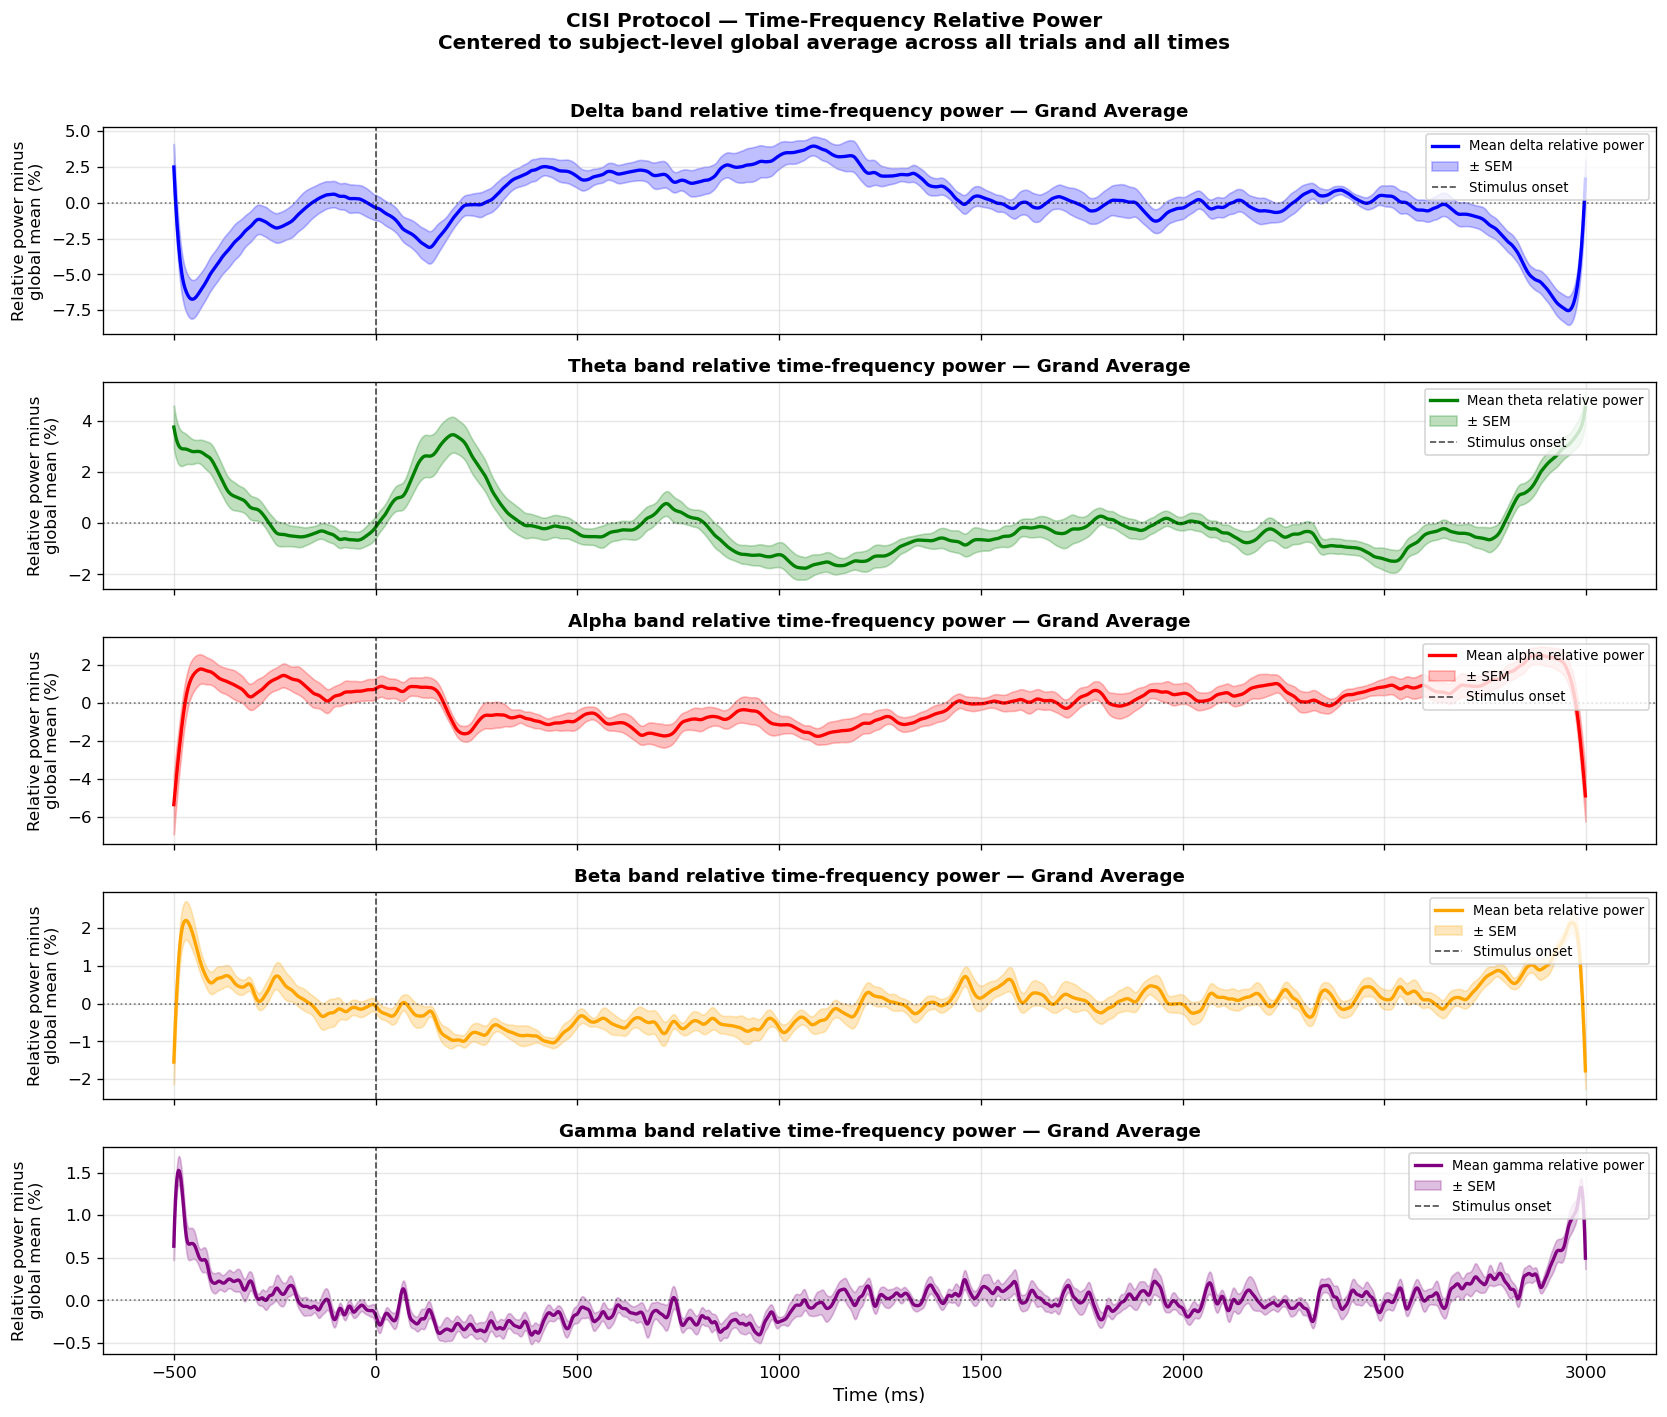

Figure saved: tf_relative_power_CISI_global_mean_centered.png


In [18]:
# ------------------------------------------------------------
# TIME-FREQUENCY RELATIVE POWER (all times)
# centered to a subject-level global mean across all trials and all times
# ------------------------------------------------------------

# These dictionaries will store, for each subject:
# - raw relative time-frequency power (trial x time)
# - one scalar baseline per band
# - centered relative time-frequency power after subtraction
tf_relative_power_pivots_raw = {}
tf_relative_global_baseline_pivots = {}
tf_relative_power_pivots_centered = {}

tf_relative_processed_subjects = []
tf_relative_failed_subjects = []

for subject_id in tf_processed_subjects:
    try:
        tf_pivot = tf_power_pivots_raw[subject_id]

        # Only keep bands that actually exist for this subject.
        available_bands = [band for band in bands if band in tf_pivot]

        if not available_bands:
            raise ValueError("No time-frequency bands available for this subject.")

        # Build the total power map at each trial x time point across bands.
        total_power_at_time = None

        for band in available_bands:
            band_pivot = tf_pivot[band].copy()

            if total_power_at_time is None:
                total_power_at_time = band_pivot.copy()
            else:
                total_power_at_time = total_power_at_time + band_pivot

        subject_raw_relative = {}
        subject_centered_relative = {}
        baseline_row = {}

        for band in available_bands:
            # Relative power is the band's share of total power at each trial x time point.
            relative_power = tf_pivot[band].div(total_power_at_time) * 100

            # One scalar baseline per subject/band:
            # average over all trials and all time points.
            relative_global_baseline = relative_power.values.mean()

            # Subtract the same scalar everywhere within that band.
            relative_power_centered = relative_power - relative_global_baseline

            subject_raw_relative[band] = relative_power
            subject_centered_relative[band] = relative_power_centered
            baseline_row[band] = relative_global_baseline

        tf_relative_power_pivots_raw[subject_id] = subject_raw_relative
        tf_relative_power_pivots_centered[subject_id] = subject_centered_relative
        tf_relative_global_baseline_pivots[subject_id] = pd.DataFrame([baseline_row], columns=bands)

        tf_relative_processed_subjects.append(subject_id)

    except Exception as e:
        tf_relative_failed_subjects.append((subject_id, str(e)))

print("Time-frequency relative-power subjects processed:", tf_relative_processed_subjects)

if tf_relative_failed_subjects:
    print("\nTime-frequency relative-power failures:")
    for subject_id, err in tf_relative_failed_subjects:
        print(f"Subject {subject_id}: {err}")

# Grand-average the centered relative power across subjects.
grand_tf_relative_power = {}
grand_tf_relative_sem = {}

for band in bands:
    band_subject_means = []

    for subject_id in tf_relative_processed_subjects:
        tf_relative_pivot = tf_relative_power_pivots_centered[subject_id]

        if band in tf_relative_pivot:
            # Mean over trials for this subject, leaving time on the x-axis.
            subject_mean = tf_relative_pivot[band].mean(axis=0)
            band_subject_means.append(subject_mean.reset_index(drop=True))

    if band_subject_means:
        band_df = pd.concat(band_subject_means, axis=1)
        grand_tf_relative_power[band] = band_df.mean(axis=1)
        grand_tf_relative_sem[band] = band_df.std(axis=1) / np.sqrt(band_df.shape[1])

# Use the same time points already established above.
first_subject = tf_relative_processed_subjects[0]
first_band = next(b for b in bands if b in tf_relative_power_pivots_centered[first_subject])
time_points = tf_relative_power_pivots_centered[first_subject][first_band].columns.values

fig, axes = plt.subplots(len(bands), 1, figsize=(14, 12), sharex=True)

for i, band in enumerate(bands):
    ax = axes[i]

    if band in grand_tf_relative_power:
        mean_power = grand_tf_relative_power[band].values
        errors = grand_tf_relative_sem[band].values

        ax.plot(time_points, mean_power, color=colors[i], linewidth=2, label=f'Mean {band} relative power')
        ax.fill_between(
            time_points,
            mean_power - errors,
            mean_power + errors,
            color=colors[i],
            alpha=0.25,
            label='± SEM'
        )

        ax.axvline(0, color='k', linestyle='--', linewidth=1, alpha=0.7, label='Stimulus onset')
        ax.axhline(0, color='black', linestyle=':', linewidth=1, alpha=0.5)

    ax.set_ylabel('Relative power minus\nglobal mean (%)', fontsize=10)
    ax.set_title(
        f'{band.capitalize()} band relative time-frequency power — Grand Average',
        fontsize=11,
        fontweight='bold'
    )
    ax.grid(True, alpha=0.3)
    ax.legend(loc='upper right', fontsize=8)

axes[-1].set_xlabel('Time (ms)', fontsize=11)
fig.suptitle(
    'CISI Protocol — Time-Frequency Relative Power\n'
    'Centered to subject-level global average across all trials and all times',
    fontsize=12,
    fontweight='bold'
)

plt.tight_layout(rect=[0, 0, 1, 0.97])
plt.savefig('tf_relative_power_CISI_global_mean_centered.png', bbox_inches='tight', dpi=150)
plt.show()

print("Figure saved: tf_relative_power_CISI_global_mean_centered.png")


Unfiltered subjects processed: [2, 3, 5, 6, 7, 8, 9, 10, 11, 12, 13, 15, 16, 17]
Filtered subjects processed: [2, 3, 5, 6, 7, 8, 9, 10, 11, 12, 13, 15, 16, 17]


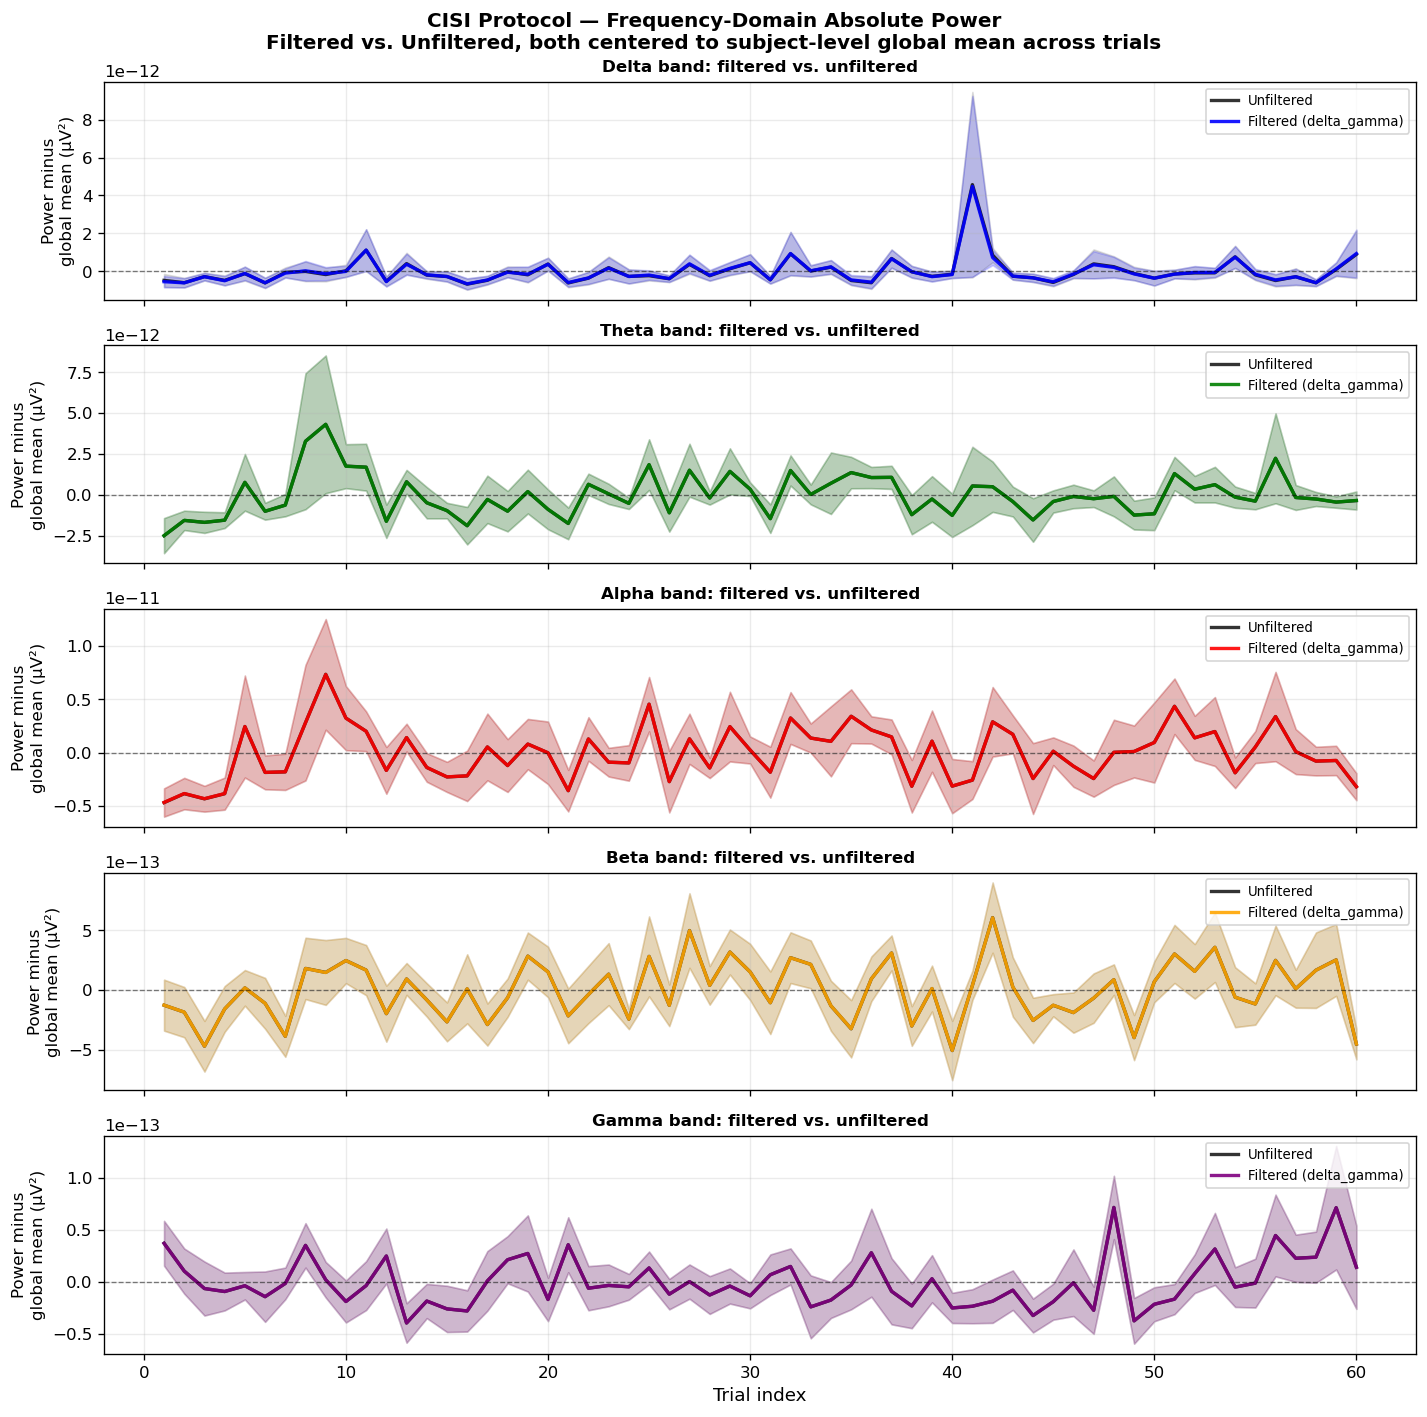

Figure saved: filtered_vs_unfiltered_frequency_power_CISI_global_mean_centered.png


In [19]:
# ------------------------------------------------------------
# FILTERED VS. UNFILTERED FREQUENCY-DOMAIN ABSOLUTE POWER
# both centered with the same global-baseline method
# ------------------------------------------------------------

# This section compares two versions of the same analysis:
# 1) unfiltered epochs
# 2) epochs loaded with the delta_gamma filter
#
# In BOTH cases, the baseline method is the same:
# compute raw trial-by-band power first, then subtract one subject-level
# across-trial mean for each band.

FILTER_BAND = "delta_gamma"

# Store raw and centered power separately for unfiltered and filtered data.
all_power_pivots_unfiltered_raw = {}
all_power_pivots_unfiltered_centered = {}

all_power_pivots_filtered_raw = {}
all_power_pivots_filtered_centered = {}

processed_unfiltered = []
processed_filtered = []
failed_unfiltered = []
failed_filtered = []

for subject_id in SUBJECTS:

    # ---------------------------
    # UNFILTERED DATA
    # ---------------------------
    try:
        with warnings.catch_warnings():
            warnings.simplefilter("ignore")
            with contextlib.redirect_stdout(io.StringIO()), contextlib.redirect_stderr(io.StringIO()):

                # Try requesting the raw epochs with no named band filter.
                epochs_unfiltered = load_eeg_data(
                    CONDITION,
                    subject_id,
                    channels=CHANNELS
                )

                power_df_unf, _ = compute_frequency_power(epochs_unfiltered, fmin=0.5, fmax=45)

        power_pivot_unf = (
            power_df_unf.groupby(['trial', 'band'])['power']
            .mean()
            .unstack()
            .reindex(columns=bands)
        )

        baseline_unf = power_pivot_unf.mean(axis=0)
        power_pivot_unf_centered = power_pivot_unf - baseline_unf

        all_power_pivots_unfiltered_raw[subject_id] = power_pivot_unf
        all_power_pivots_unfiltered_centered[subject_id] = power_pivot_unf_centered
        processed_unfiltered.append(subject_id)

    except Exception as e:
        failed_unfiltered.append((subject_id, str(e)))

    # ---------------------------
    # FILTERED DATA
    # ---------------------------
    try:
        with warnings.catch_warnings():
            warnings.simplefilter("ignore")
            with contextlib.redirect_stdout(io.StringIO()), contextlib.redirect_stderr(io.StringIO()):

                epochs_filtered = load_eeg_data(
                    CONDITION,
                    subject_id,
                    channels=CHANNELS,
                    freq_band=FILTER_BAND
                )

                power_df_filt, _ = compute_frequency_power(epochs_filtered, fmin=0.5, fmax=45)

        power_pivot_filt = (
            power_df_filt.groupby(['trial', 'band'])['power']
            .mean()
            .unstack()
            .reindex(columns=bands)
        )

        baseline_filt = power_pivot_filt.mean(axis=0)
        power_pivot_filt_centered = power_pivot_filt - baseline_filt

        all_power_pivots_filtered_raw[subject_id] = power_pivot_filt
        all_power_pivots_filtered_centered[subject_id] = power_pivot_filt_centered
        processed_filtered.append(subject_id)

    except Exception as e:
        failed_filtered.append((subject_id, str(e)))

print("Unfiltered subjects processed:", processed_unfiltered)
print("Filtered subjects processed:", processed_filtered)

if failed_unfiltered:
    print("\nUnfiltered failures:")
    for subject_id, err in failed_unfiltered:
        print(f"Subject {subject_id}: {err}")

if failed_filtered:
    print("\nFiltered failures:")
    for subject_id, err in failed_filtered:
        print(f"Subject {subject_id}: {err}")

# Build grand-average tables for each version.
grand_power_unfiltered = {}
grand_sem_unfiltered = {}
grand_power_filtered = {}
grand_sem_filtered = {}

for band in bands:
    band_trials_unf = []
    band_trials_filt = []

    for subject_id in processed_unfiltered:
        power_pivot = all_power_pivots_unfiltered_centered[subject_id]
        if band in power_pivot.columns:
            band_trials_unf.append(power_pivot[band].reset_index(drop=True))

    for subject_id in processed_filtered:
        power_pivot = all_power_pivots_filtered_centered[subject_id]
        if band in power_pivot.columns:
            band_trials_filt.append(power_pivot[band].reset_index(drop=True))

    if band_trials_unf:
        band_df_unf = pd.concat(band_trials_unf, axis=1)
        grand_power_unfiltered[band] = band_df_unf.mean(axis=1)
        grand_sem_unfiltered[band] = band_df_unf.std(axis=1) / np.sqrt(band_df_unf.shape[1])

    if band_trials_filt:
        band_df_filt = pd.concat(band_trials_filt, axis=1)
        grand_power_filtered[band] = band_df_filt.mean(axis=1)
        grand_sem_filtered[band] = band_df_filt.std(axis=1) / np.sqrt(band_df_filt.shape[1])

# Plot the two versions on the same axes for each band.
fig, axes = plt.subplots(len(bands), 1, figsize=(12, 12), sharex=True)

for i, band in enumerate(bands):
    ax = axes[i]

    if band in grand_power_unfiltered:
        values_unf = grand_power_unfiltered[band].values
        errors_unf = grand_sem_unfiltered[band].values
        trial_idx_unf = np.arange(1, len(values_unf) + 1)

        ax.plot(
            trial_idx_unf,
            values_unf,
            color='black',
            linewidth=2.0,
            alpha=0.8,
            label='Unfiltered'
        )

        ax.fill_between(
            trial_idx_unf,
            values_unf - errors_unf,
            values_unf + errors_unf,
            color='black',
            alpha=0.12
        )

    if band in grand_power_filtered:
        values_filt = grand_power_filtered[band].values
        errors_filt = grand_sem_filtered[band].values
        trial_idx_filt = np.arange(1, len(values_filt) + 1)

        ax.plot(
            trial_idx_filt,
            values_filt,
            color=colors[i],
            linewidth=2.0,
            alpha=0.9,
            label=f'Filtered ({FILTER_BAND})'
        )

        ax.fill_between(
            trial_idx_filt,
            values_filt - errors_filt,
            values_filt + errors_filt,
            color=colors[i],
            alpha=0.18
        )

    ax.axhline(0, color='black', linewidth=0.8, linestyle='--', alpha=0.5)
    ax.set_ylabel('Power minus\nglobal mean (µV²)', fontsize=10)
    ax.set_title(f'{band.capitalize()} band: filtered vs. unfiltered', fontsize=10, fontweight='bold')
    ax.grid(True, alpha=0.25)
    ax.legend(loc='upper right', fontsize=8)

axes[-1].set_xlabel('Trial index', fontsize=11)

fig.suptitle(
    'CISI Protocol — Frequency-Domain Absolute Power\n'
    'Filtered vs. Unfiltered, both centered to subject-level global mean across trials',
    fontsize=12,
    fontweight='bold'
)

fig.tight_layout()
plt.savefig('filtered_vs_unfiltered_frequency_power_CISI_global_mean_centered.png', bbox_inches='tight', dpi=150)
plt.show()

print("Figure saved: filtered_vs_unfiltered_frequency_power_CISI_global_mean_centered.png")
